In [1]:
import scf_test.tests as test
import numpy as np
import pyfftw
import matplotlib.pyplot as plt

In [2]:
def ssca(signal, fs=1, Np=64, conjugate=False, plot=False, coherence=False):   
    # Pad signal to make it even -> Faster fft
    N = len(signal)
    if N % 2 == 1:
        N = N + 1
        signal = np.pad(signal, (0, 1))

    if Np % 2 == 0:
        pad_length = int(Np/2)
    else:
        pad_length = int((Np-1)/2)

    # Initialize hamming windows

    window = np.hamming(Np).reshape((-1, 1))

    window_2 = np.hamming(N)
    
    window_2 = window_2/np.sum(window_2)

    conj_signal = np.conj(signal)

    # Pad signal for windowing
    signal_padded = np.pad(signal, (pad_length, pad_length))

    # Initialize memory aligned variable -> Faster fft
    Xt = pyfftw.empty_aligned((Np, N), dtype='complex')

    # Channelizer
    for i in range(Np):
        Xt[i, :] = signal_padded[i:i+N]

    # Windowing
    Xt = Xt * window

    # FFT
    Xt = np.fft.fftshift(pyfftw.interfaces.numpy_fft.fft(Xt, axis=0), axes=0)

    # Enable cache for pyfftw (faster fft)
    pyfftw.interfaces.cache.enable()
          
    # Exponential to calculate complex demodulate
    k = np.linspace(-Np/2, Np/2 - 1, Np).reshape((-1,1))
    n = np.linspace(0, N - 1, N)
    E = np.exp(-1j*2*np.pi*n*k/Np)
    
    # Multiply with original conjugated signal and second FFT
    if not conjugate:
        Xt = Xt * conj_signal * E * window_2
    else:
        Xt = Xt * signal * E * window_2

    ssca = np.abs(np.fft.fftshift(pyfftw.interfaces.numpy_fft.fft(Xt, axis=1), axes=1))

    # Map spectral and cycle frequencies to SSCA output
    q = np.linspace(-N/2, N/2 - 1, N)
    f = k/(2*Np) - q/(2*N)
    alpha = k/Np + q/N

    # Optional spectral coherence calculation from SSCA SCF
    if coherence:
        sample_1 = np.rint((f + alpha/2) * Np/fs).astype(int)
        if conjugate:
            sample_2 = np.rint((alpha/2 - f) * Np/fs).astype(int)
        else:
            sample_2 = np.rint((f - alpha/2) * Np/fs).astype(int)

        smoothing_width = int(0.02 * N) # 2% sampling rate

        psd_fsm = np.fft.ifftshift(psd(signal, L=Np, method="bartlett", db=False, plot=False))

        coherence_denominator = np.sqrt(psd_fsm[sample_1] * psd_fsm[sample_2])

        ssca_coh = ssca/coherence_denominator

    # Optional plot option (Not very good)
    if plot:
        plt.figure(figsize=(6, 6))

        # FSM method for visual only
        # ssca_smooth = scipy.signal.oaconvolve(ssca, 1/256 * np.ones((1, 256)), mode = "same")

        if coherence:
            plt.pcolormesh(f, alpha, ssca_coh)
        else:
            plt.pcolormesh(f, alpha, ssca)

        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Cycle Frequency (Hz)")
        if conjugate:
            plt.title("Conj SSCA")
        else:
            plt.title("SSCA")

    if coherence:
        return ssca_coh, f, alpha 
    else:
        return ssca, f, alpha 

def fam(signal, Np=64, L=16, conjugate=False, plot=False, coherence=False, fs=1):
    # L check
    if L < 1:
        L = 1
    
    # Pad signal (ensure that it is even -> fast fft)
    N = len(signal)
    if N % 2 == 1:
        N = N + 1
        signal = np.pad(signal, (0, 1))

    if Np % 2 == 1:
        Np = Np + 1

    # Pad signal more due to hopping
    P = int(np.floor(N / L))

    pad_length = int(Np - (N - P * L))

    pad_length = int(pad_length/2)
    
    signal_padded = np.pad(signal, (pad_length, pad_length))

    # Normalize energy and power on window to get correct PSD magnitude
    window = np.hamming(Np).reshape((-1, 1))

    window = window/ np.sqrt(np.sum(window**2))

    window_2 = np.hamming(P)
    
    window_2 = window_2 / np.sum(window_2)

    N = len(signal_padded)

    L = int(L)

    Xt = pyfftw.empty_aligned((Np, P), dtype='complex')

    # Channelize signal with hop
    for i in range(Np):
        Xt[i, :] = signal_padded[i:i + P*L:L]

    # Apply windowing function
    Xt = Xt * window

    Xt_conj = np.conj(Xt)

    # Enable cache for pyfftw (faster fft)
    pyfftw.interfaces.cache.enable()

    # FFT + Phase compensation
    Xt = np.fft.fftshift(pyfftw.interfaces.numpy_fft.fft(Xt, axis=0), axes=0)

    fk = np.fft.fftshift(np.fft.fftfreq(Np))

    i = np.arange(P)

    phase_compensation = np.exp(-1j*2*np.pi*fk.reshape((-1,1))*i*L)

    # Forming Yt*
    if conjugate:
        Yt_conj = np.fft.fftshift(pyfftw.interfaces.numpy_fft.fft(Xt_conj, axis=0), axes=0)
        Yt_conj = np.conj(Yt_conj * phase_compensation)
        Xt = Xt * phase_compensation 
    else:
        Xt = Xt * phase_compensation 
        Yt_conj = np.conj(Xt)

    # Frequency and alpha mapping calculation
    # alpha_i = fk - fl
    # alpha = alpha_i + q * delta_alpha = alpha_i + q/N
    # fj = (fk + fl)/2 = (k + l)/(2*L)
    
    fl = np.tile(fk.reshape((-1,1)), P)

    # Retain q in this range to minimize variability near top and bottom of channel pair region
    q_lim = int(P*L/(2*Np))

    q_size = q_lim*2

    q = np.arange(q_size) - q_lim
    delta_alpha = q/N

    fam = pyfftw.empty_aligned((Np * Np, q_size), dtype='float')
    fj = np.zeros((Np * Np, q_size), dtype='float')
    alpha = np.zeros((Np * Np, q_size), dtype='float')

    l = np.tile(np.arange(Np).reshape((-1, 1)), q_size) 

    # Multiply rows of Xt to Yt* and window + fft
    for k in range(Np):
        fj[k*Np:(k+1)*Np, :] = (k + l - Np)/(2*Np) 
        fam[k*Np:(k+1)*Np, :] = np.abs(pyfftw.interfaces.numpy_fft.fft(Xt[k, :] * Yt_conj * window_2, axis=1))[:, q]
        alpha[k*Np:(k+1)*Np, :] = (k - l)/Np + delta_alpha 

    # Remove any value outside the principal diamond
    # mask = np.abs(fj) + np.abs(alpha/2) > 0.5

    #fam[mask] = 0

    fam = fam.reshape((Np, Np*q_size))
    fj = fj.reshape((Np, Np*q_size))
    alpha = alpha.reshape((Np, Np*q_size))
    
    # Optional spectral coherence calculation from SSCA SCF
    if coherence:
        N = Np
        
        sample_1 = np.rint((fj + alpha/2) * N/fs).astype(int)
        if conjugate:
            sample_2 = np.rint((alpha/2 - fj) * N/fs).astype(int)
        else:
            sample_2 = np.rint((fj - alpha/2) * N/fs).astype(int)

        smoothing_width = int(0.02 * N) # 15% sampling rate

        psd_fsm = np.fft.ifftshift(psd(signal, L=Np, method="bartlett", db=False, plot=False))

        coherence_denominator = np.sqrt(psd_fsm[sample_1] * psd_fsm[sample_2])

        fam_coh = fam/coherence_denominator

    if plot:
        plt.figure(figsize=(6, 6))
        plt.pcolormesh(fj, alpha, fam)

        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Cycle Frequency (Hz)")
        if conjugate:
            plt.title("Conj FAM")
        else:
            plt.title("FAM")

    if coherence:
        return fam_coh, fj, alpha 
    else:
        return fam, fj, alpha 

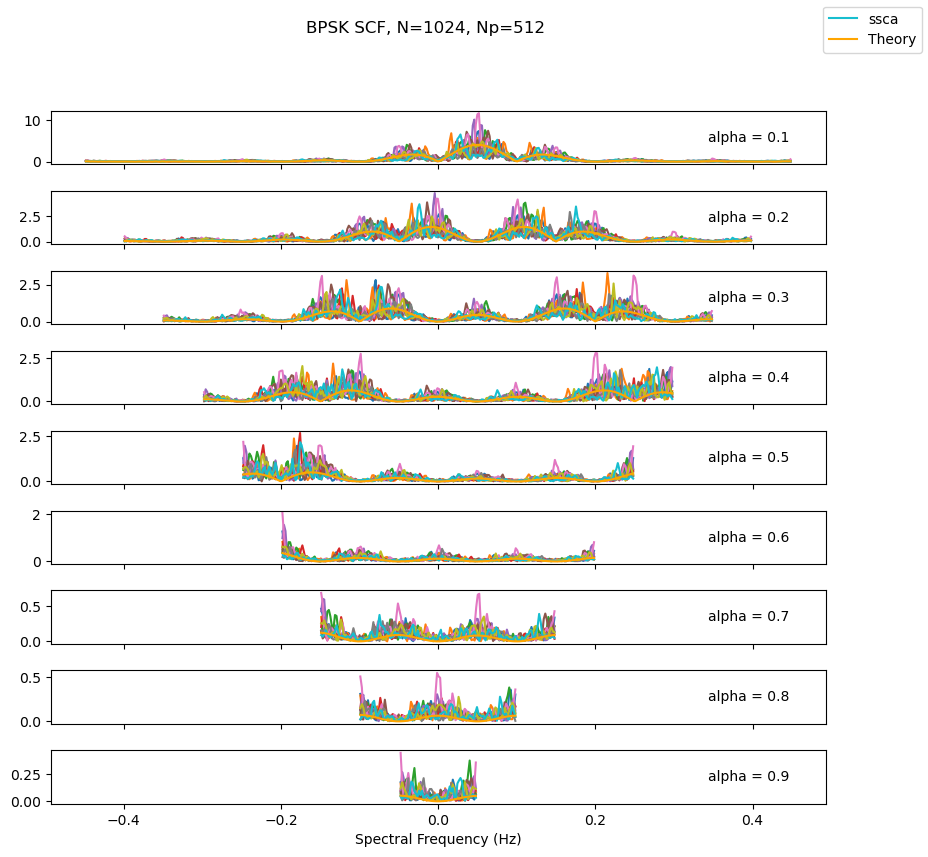

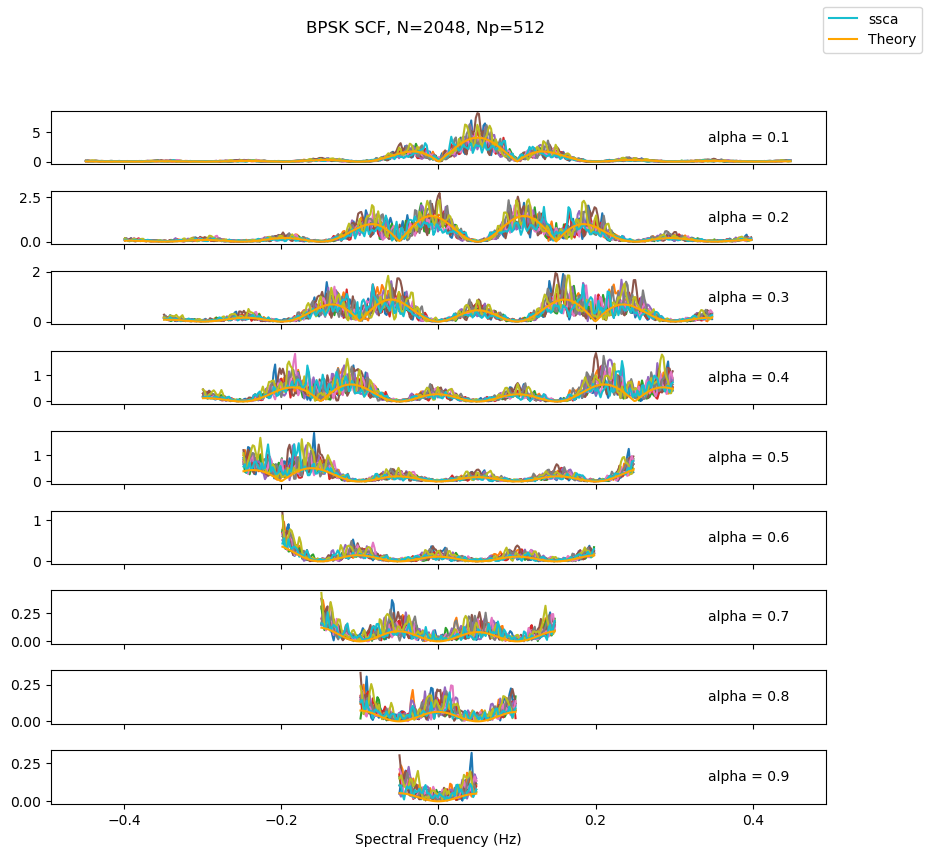

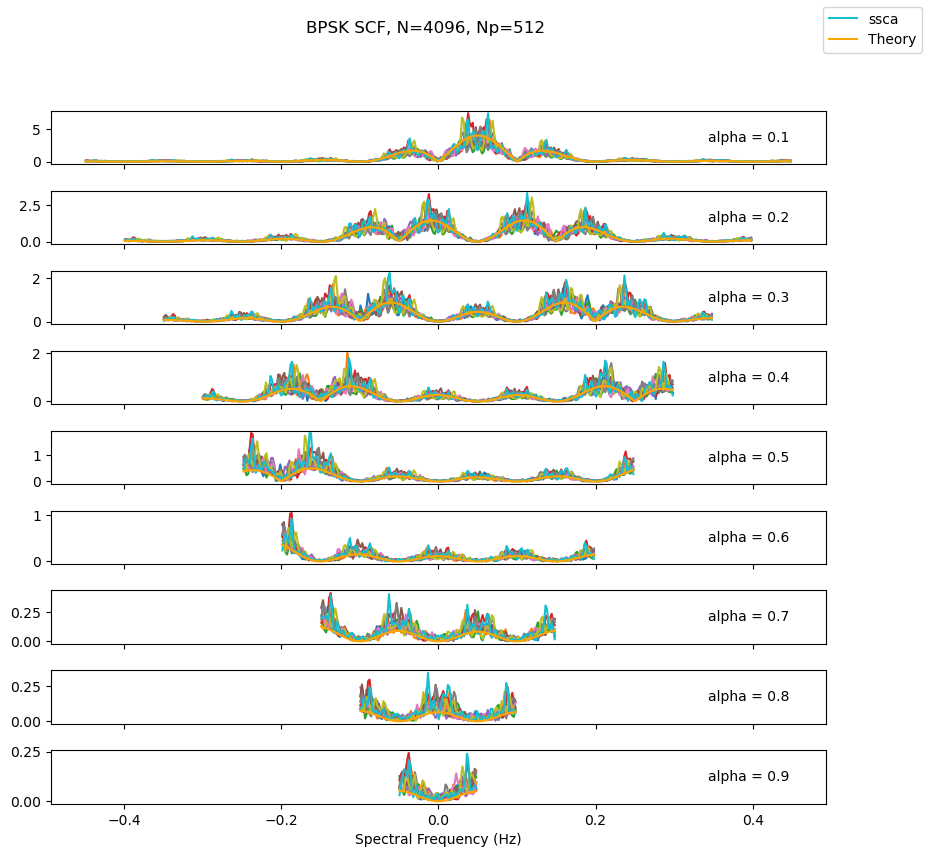

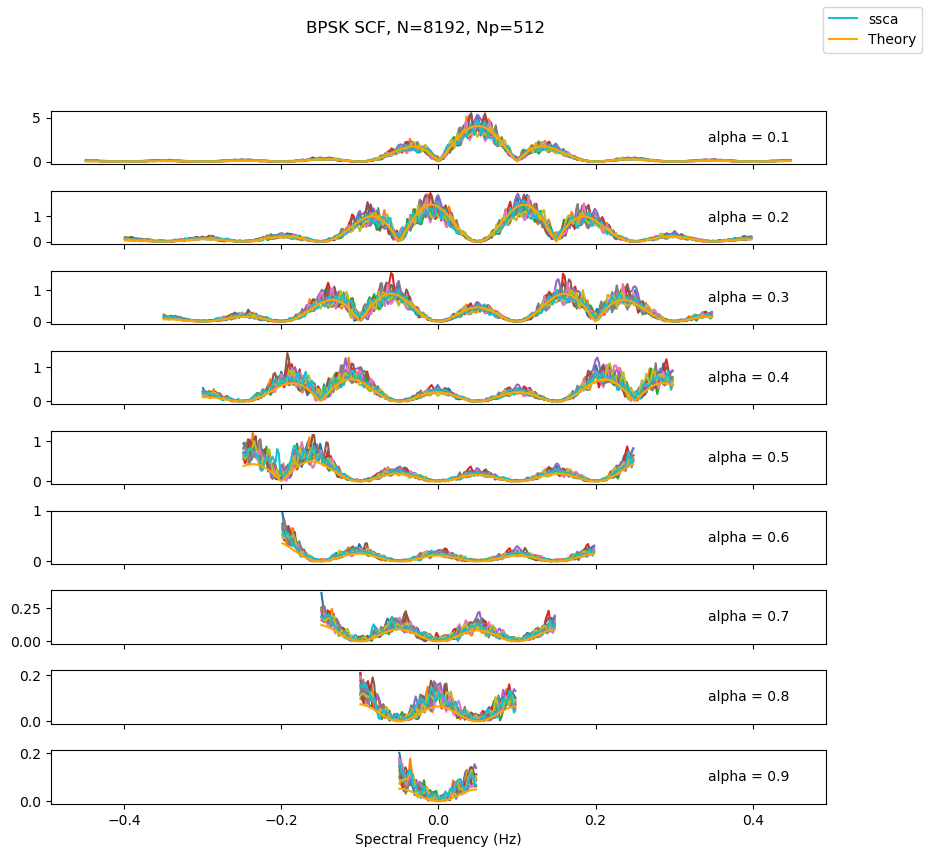

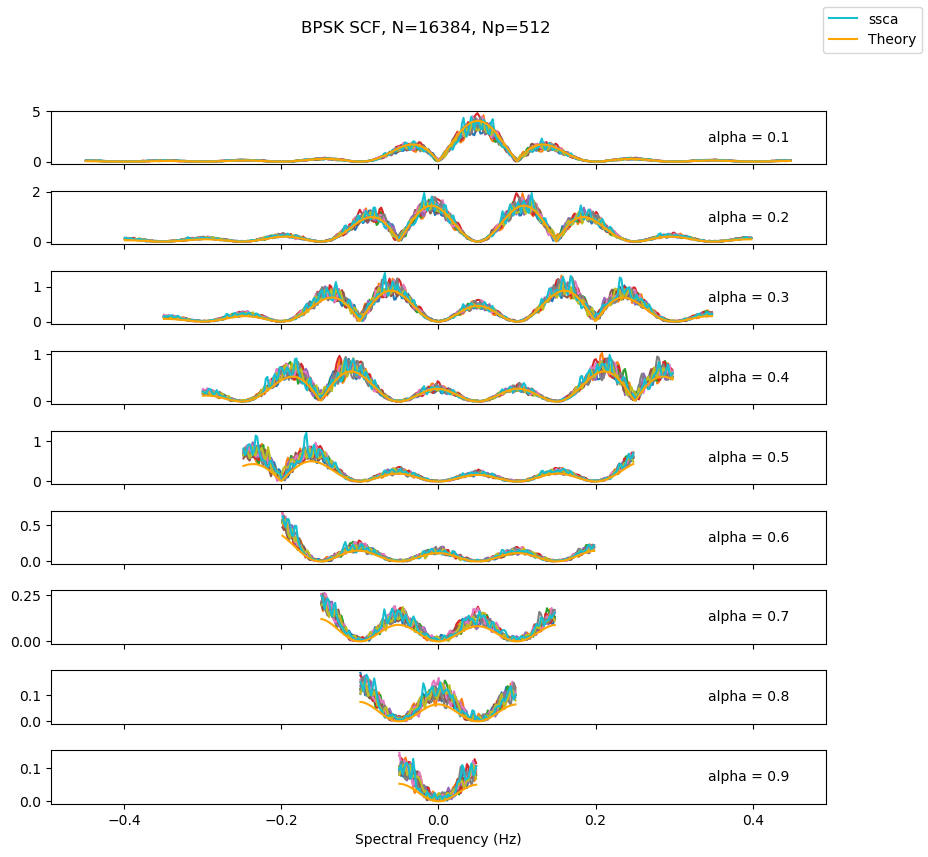

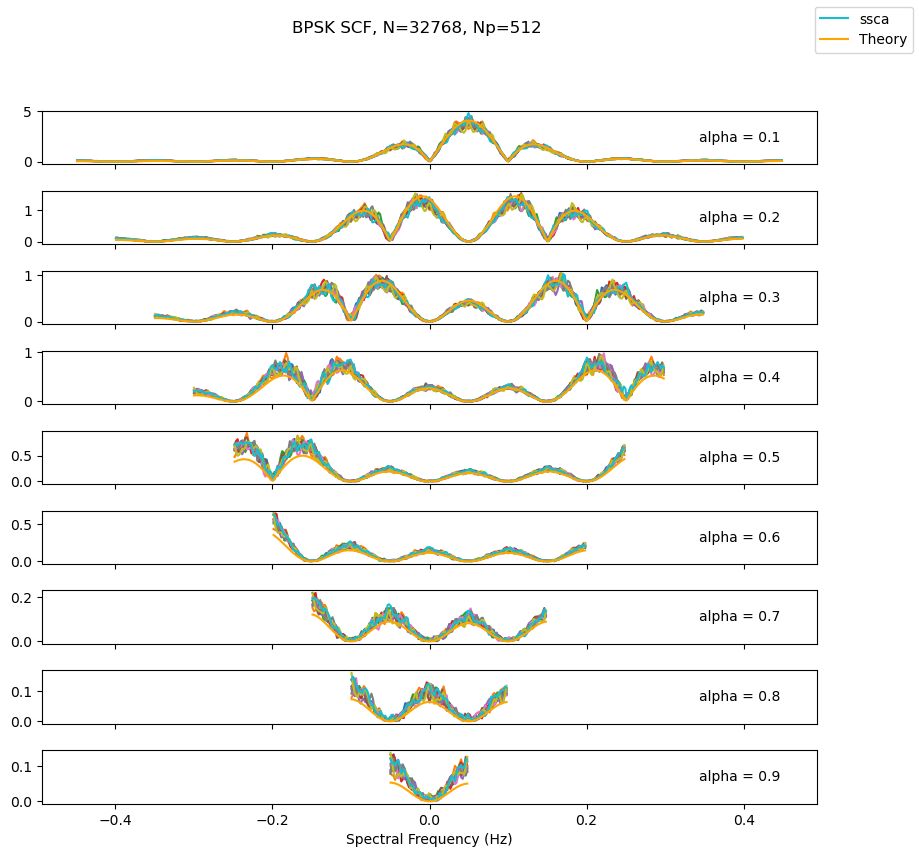

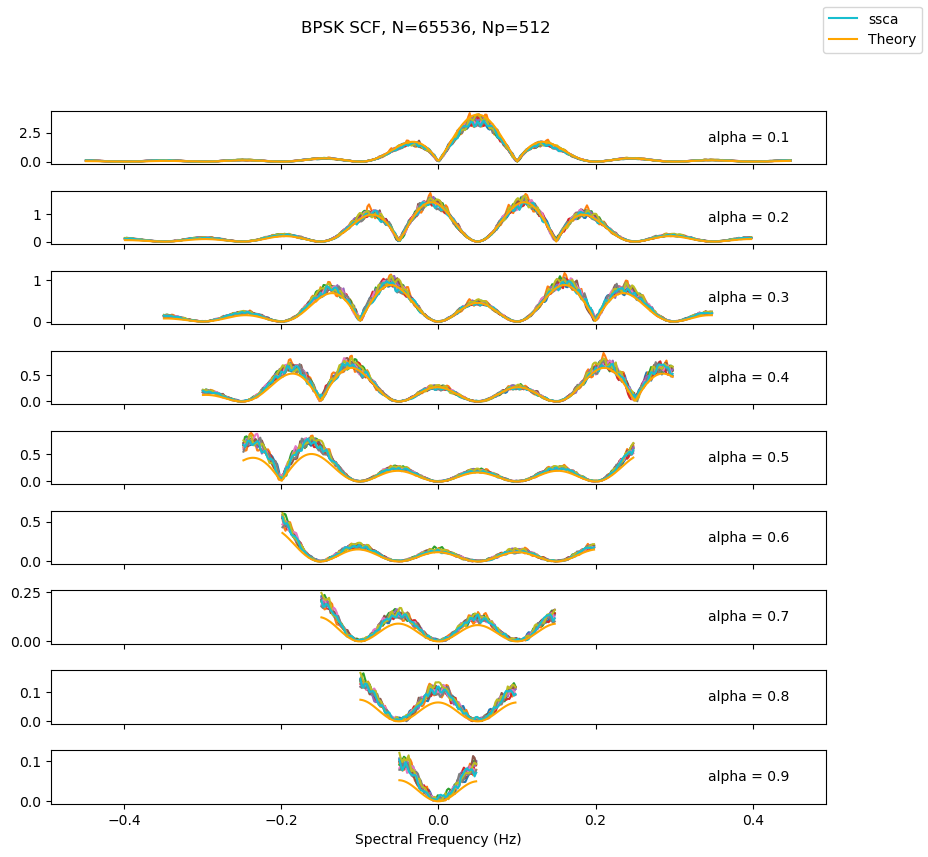

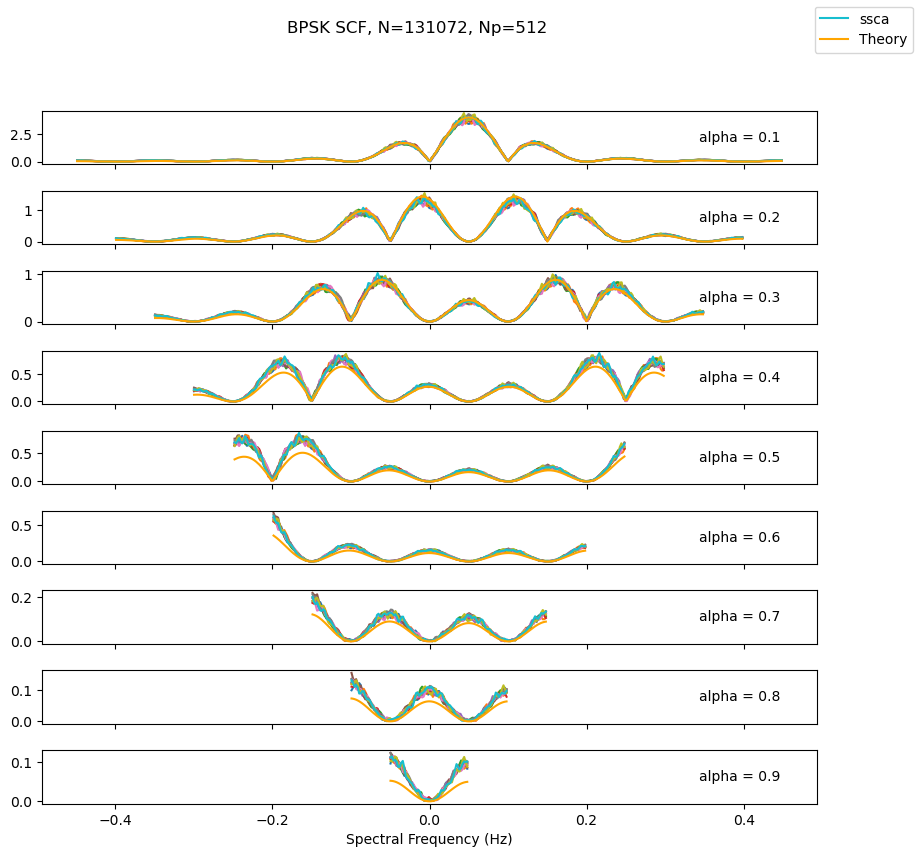

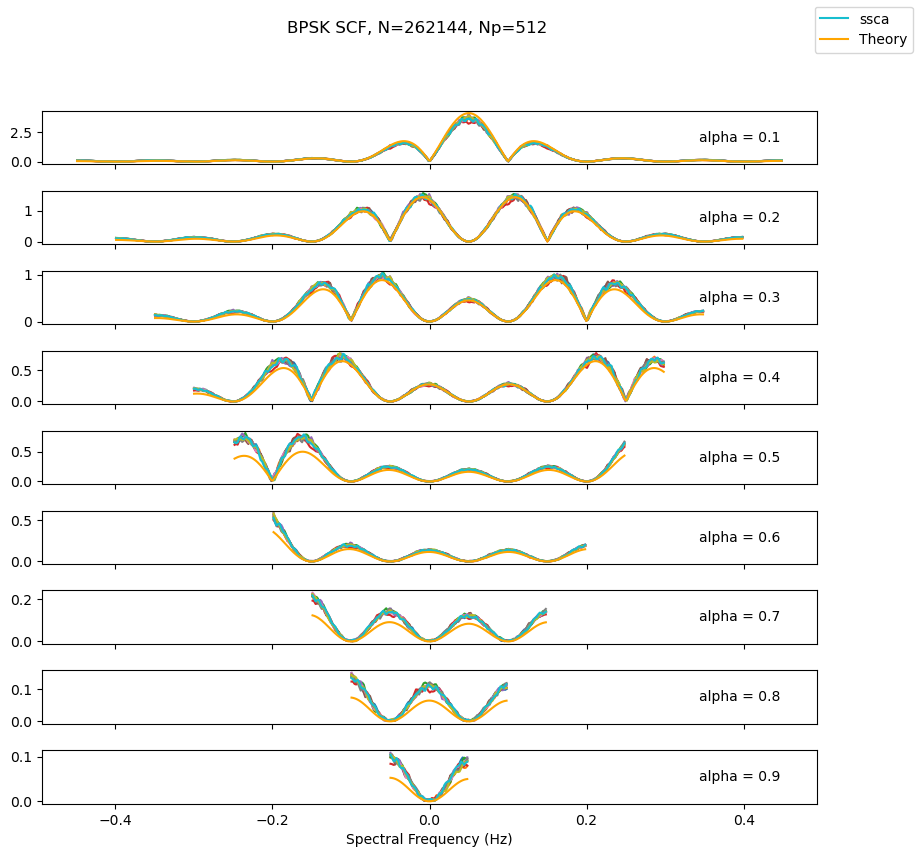

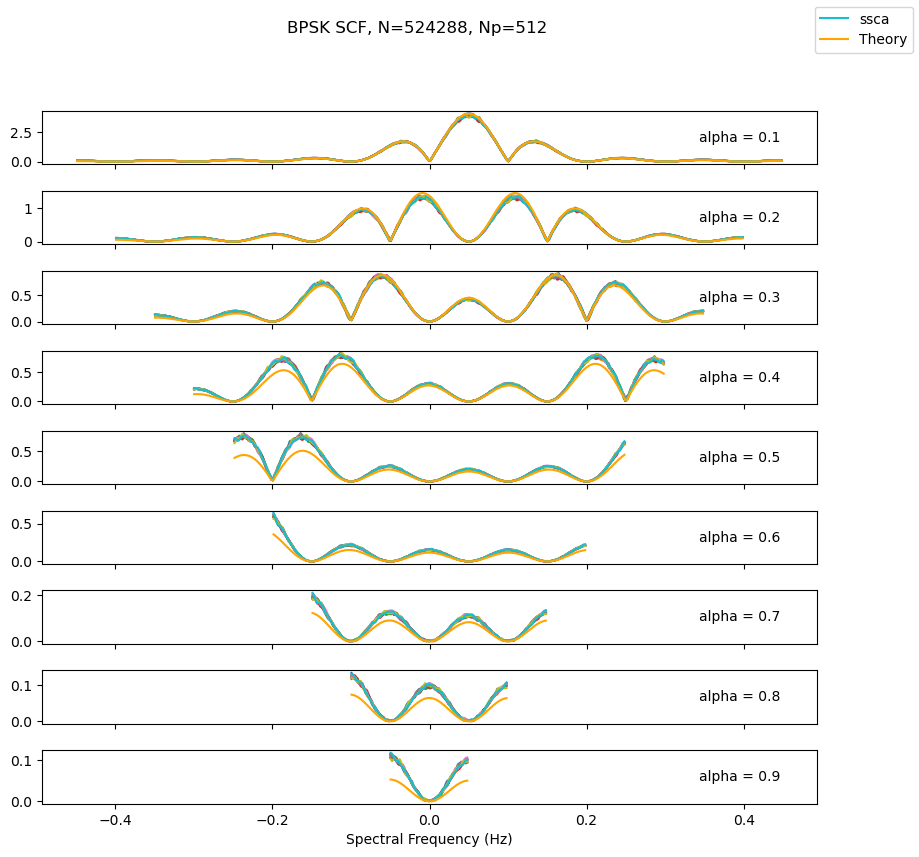

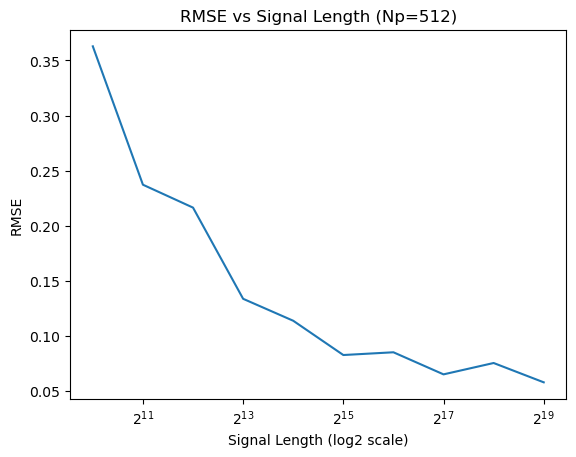

In [4]:
ssca_rmse, no_of_points = test.validation_test(ssca, name="ssca", Np=512, snr=10, no_of_run=10, conjugate=False, save=True)

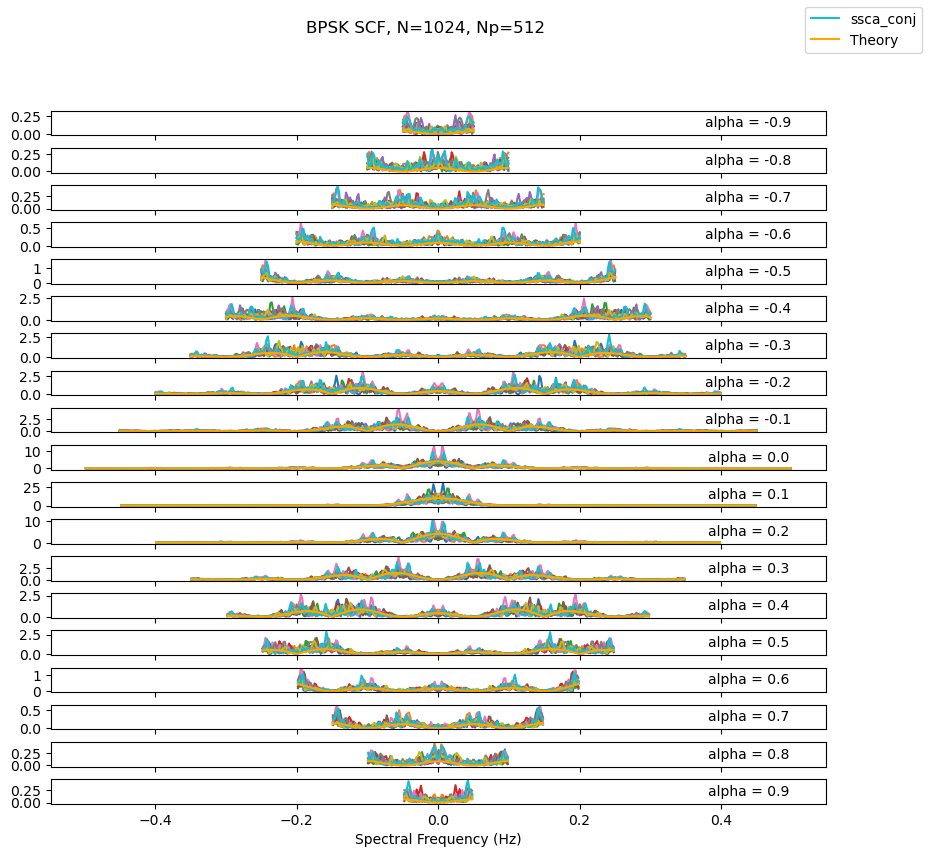

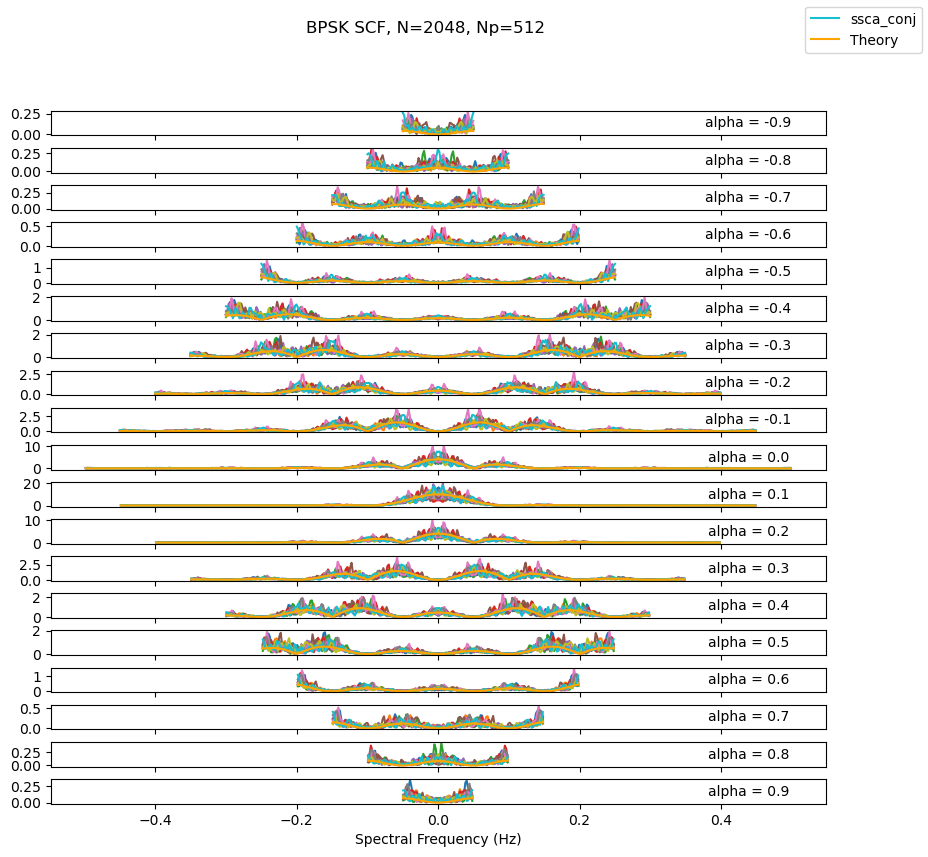

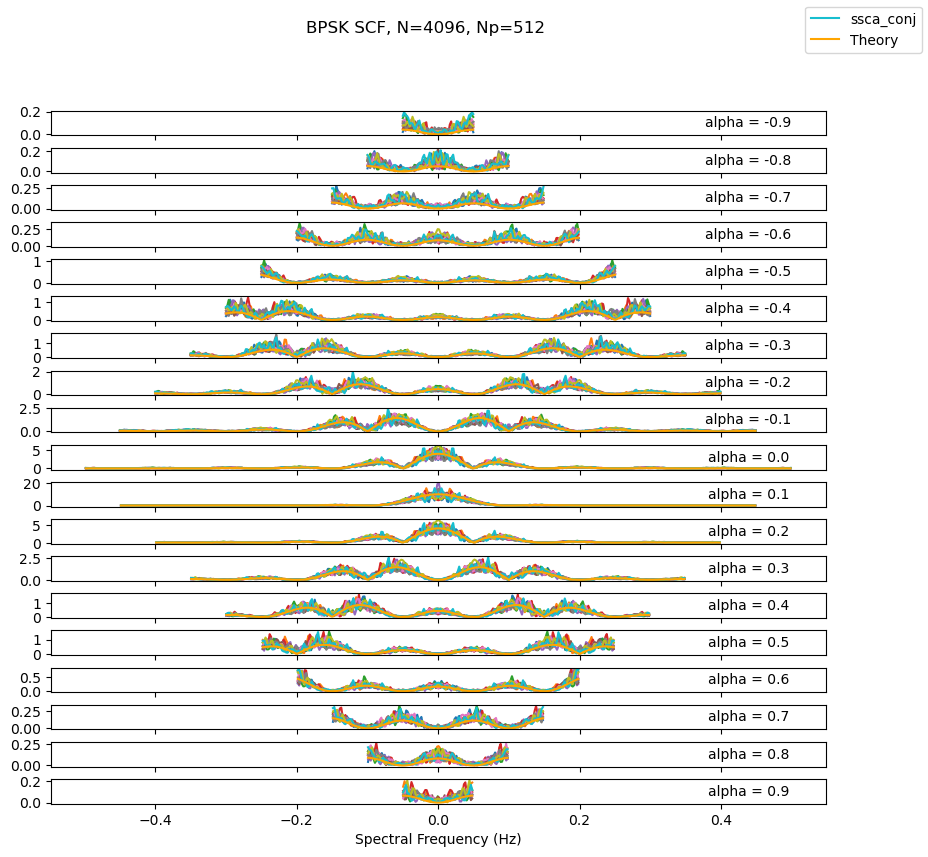

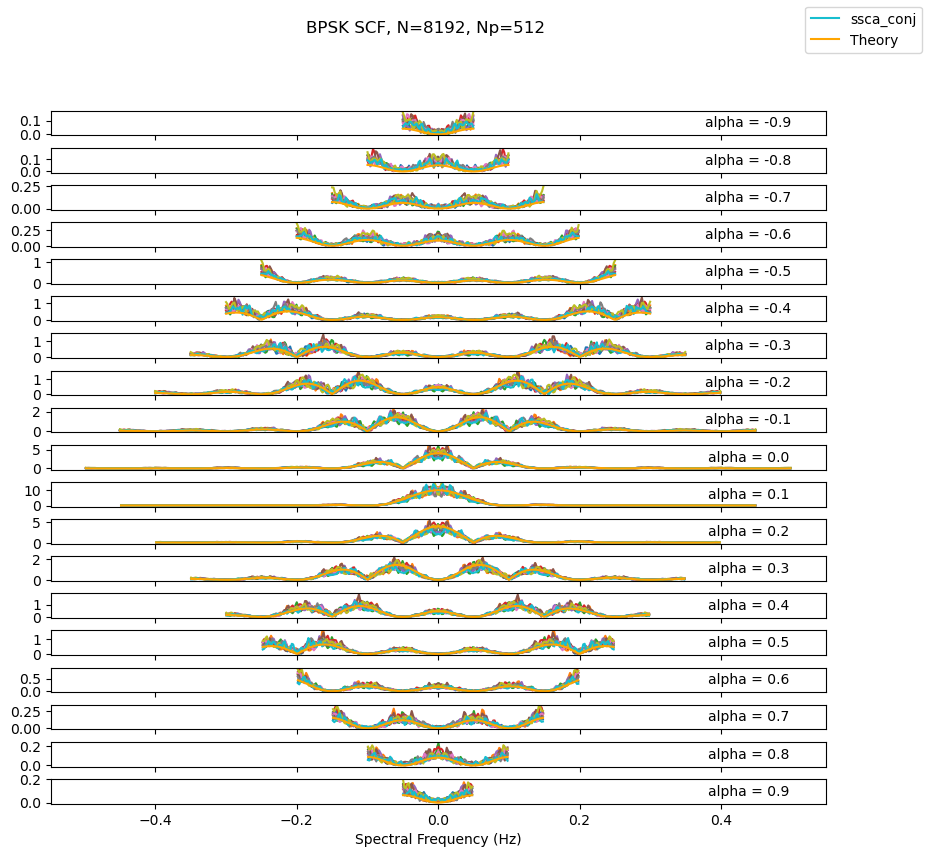

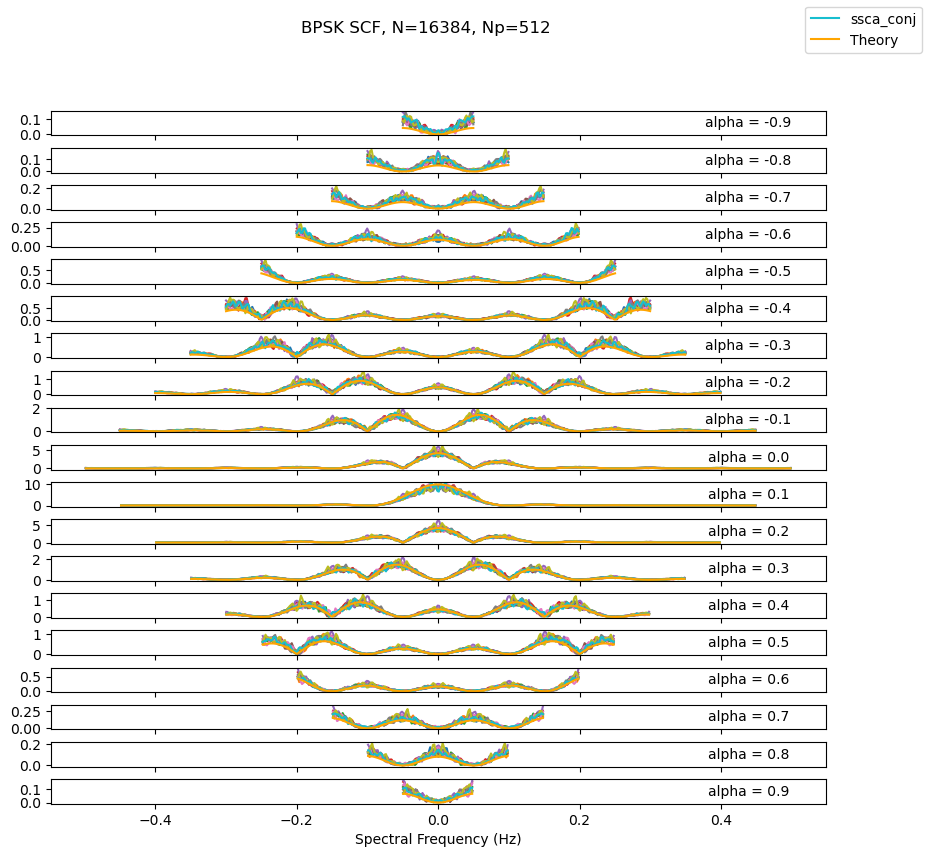

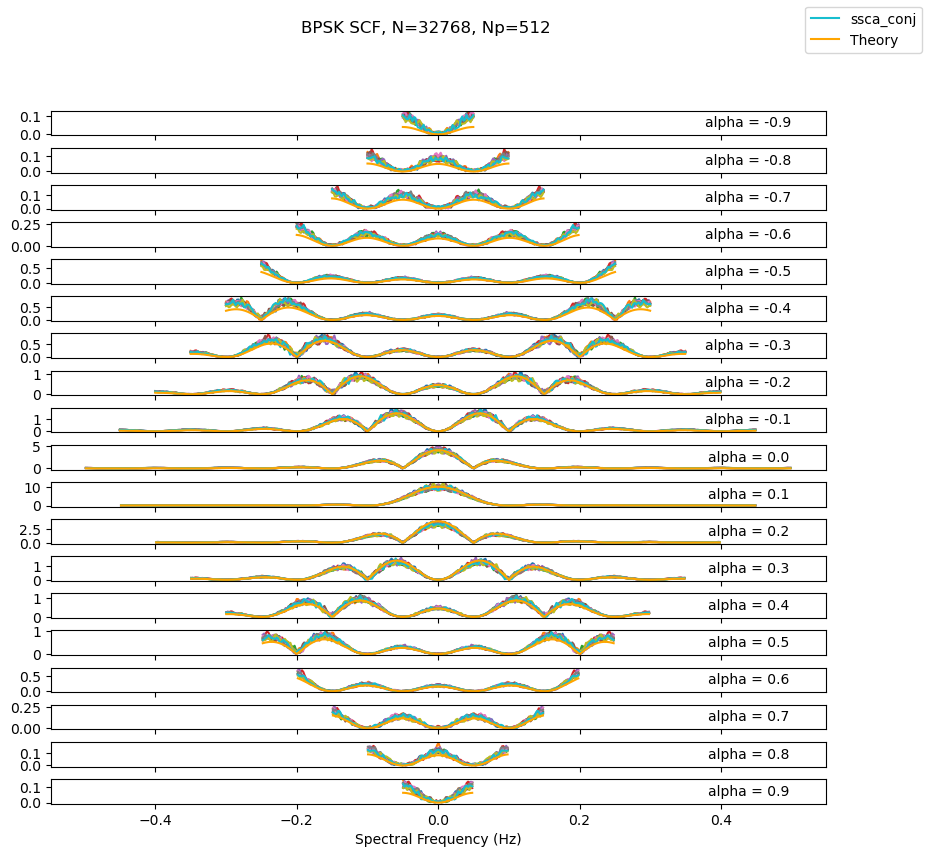

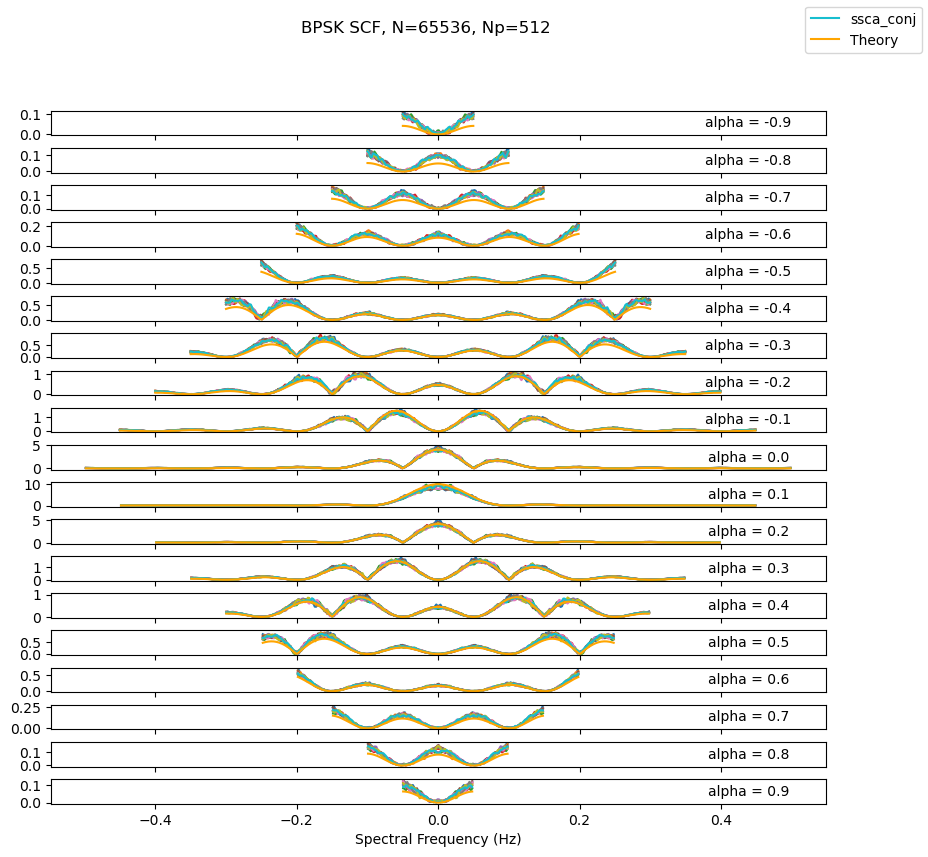

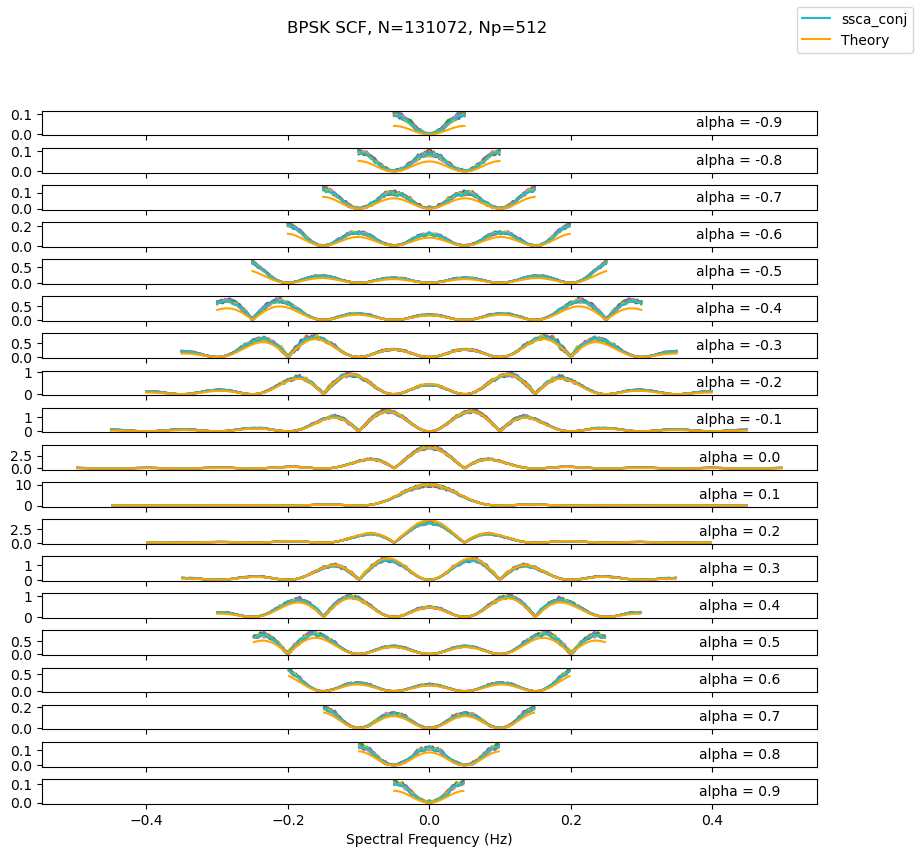

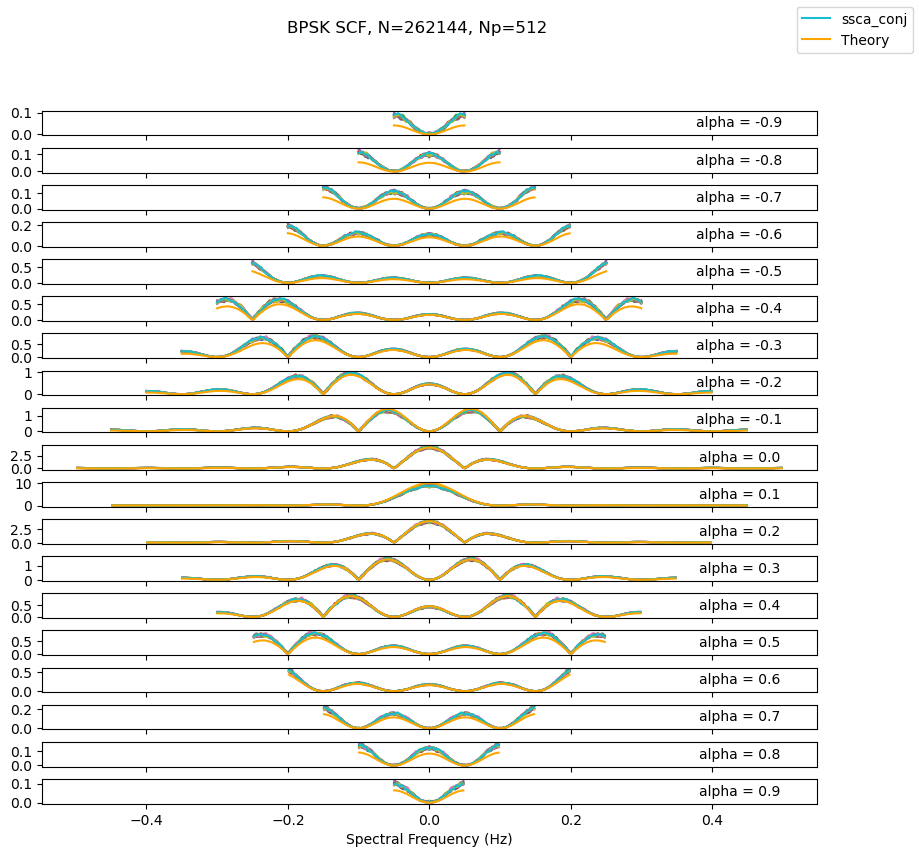

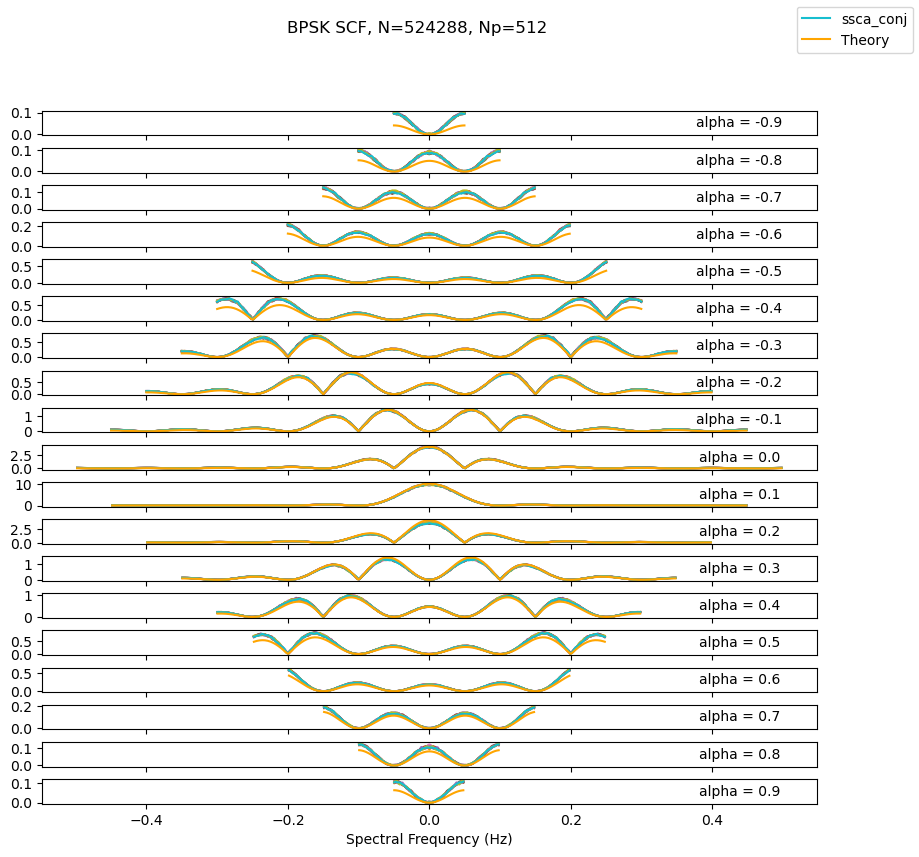

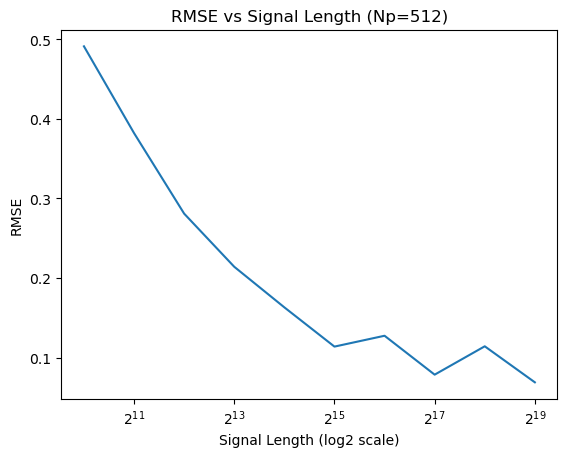

In [5]:
ssca_conj_rmse, no_of_points = test.validation_test(ssca, name="ssca_conj", Np=512, snr=10, no_of_run=10, conjugate=True, save=True)

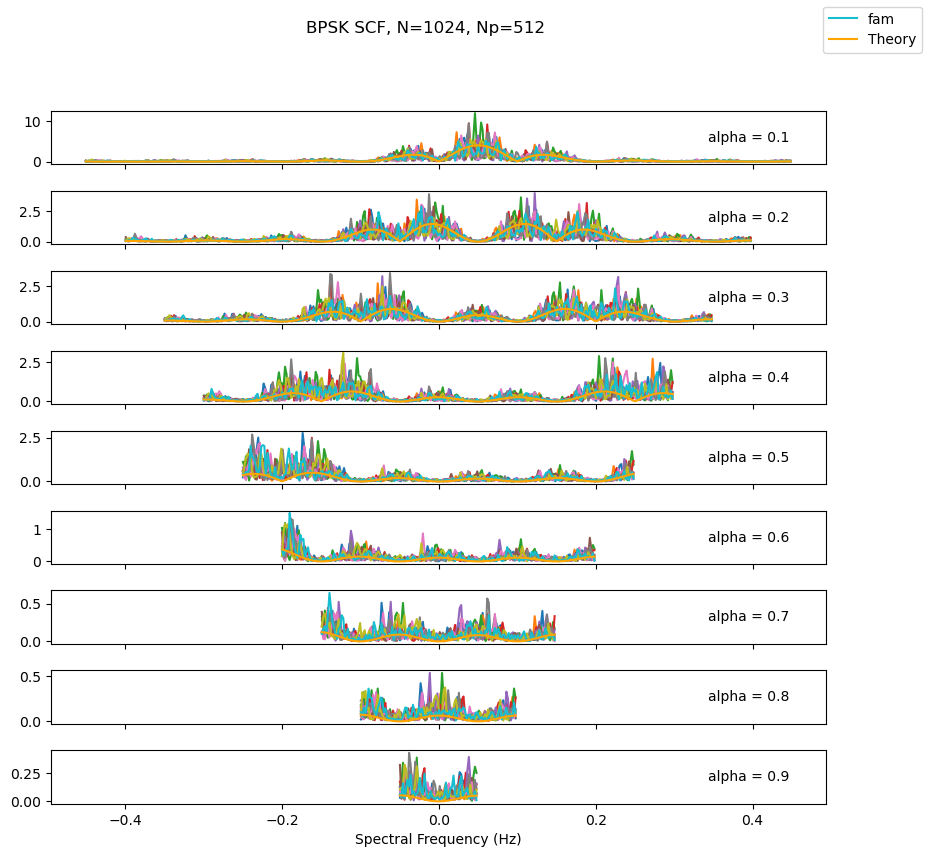

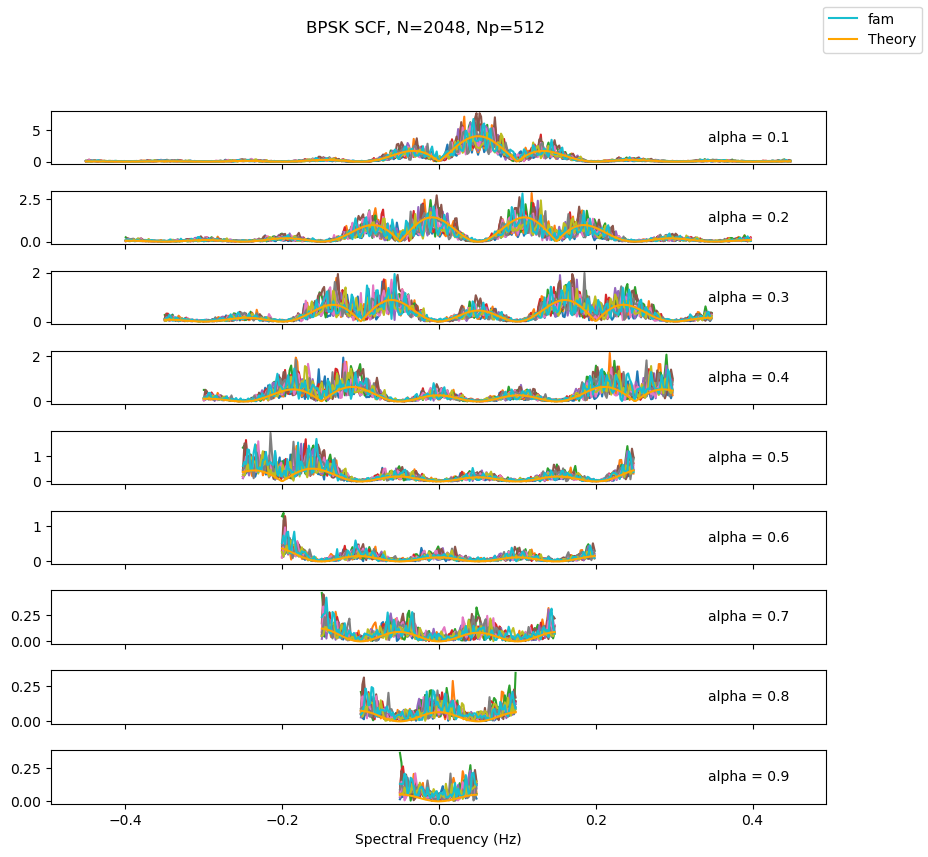

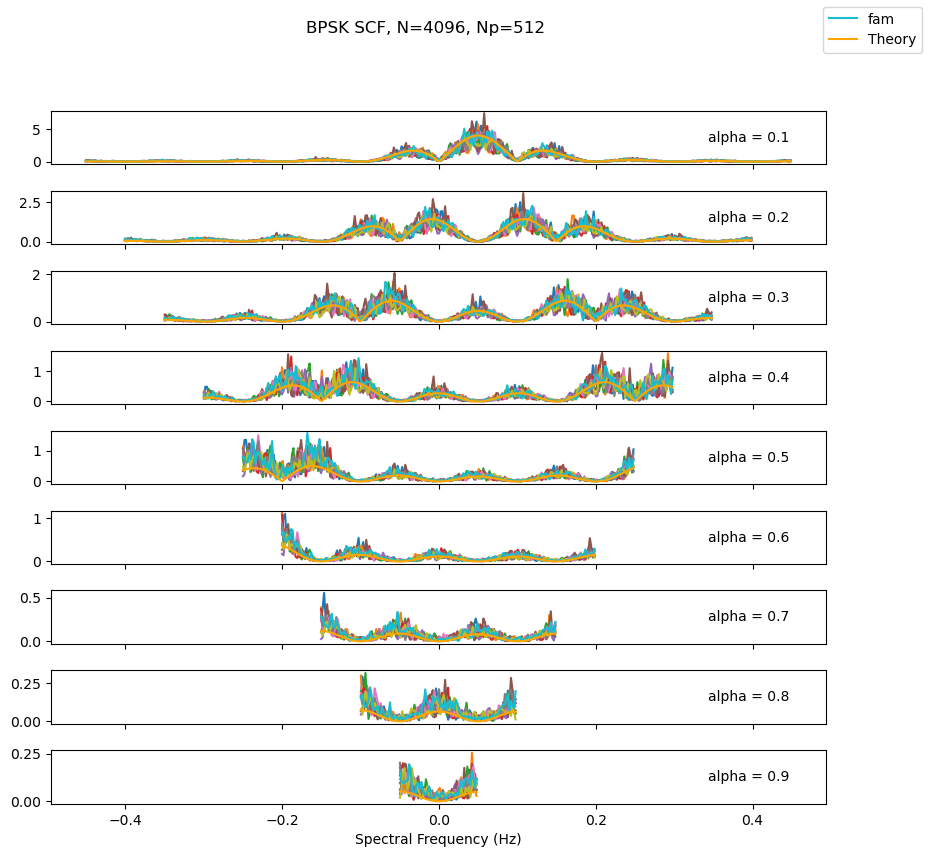

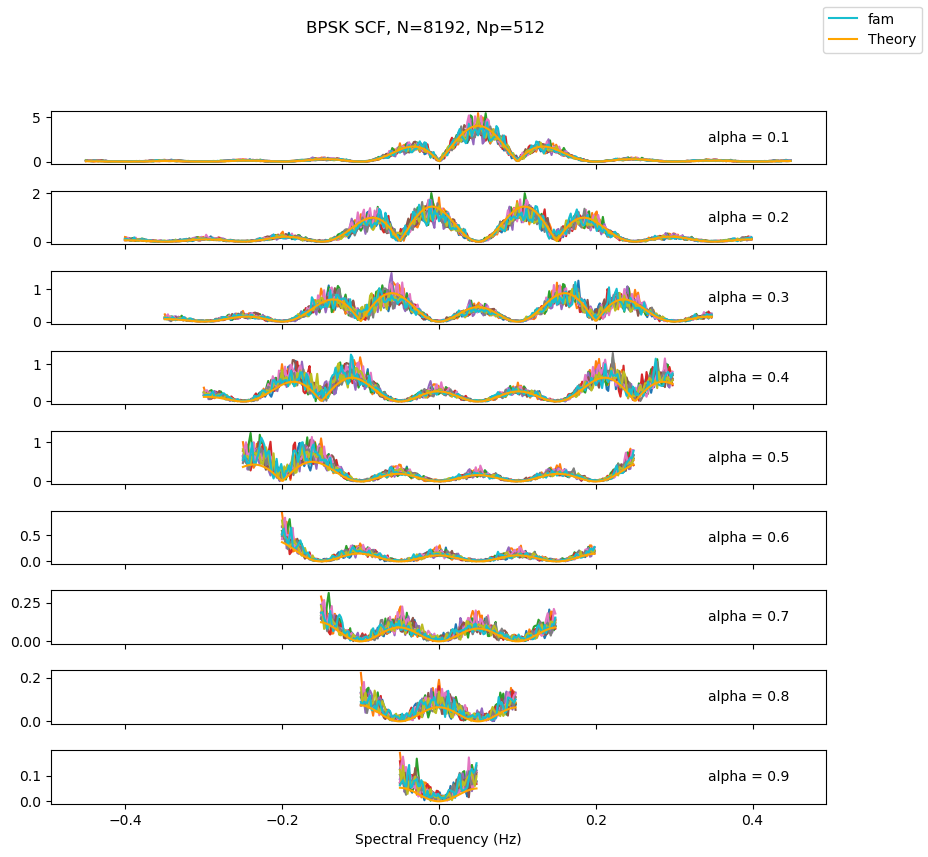

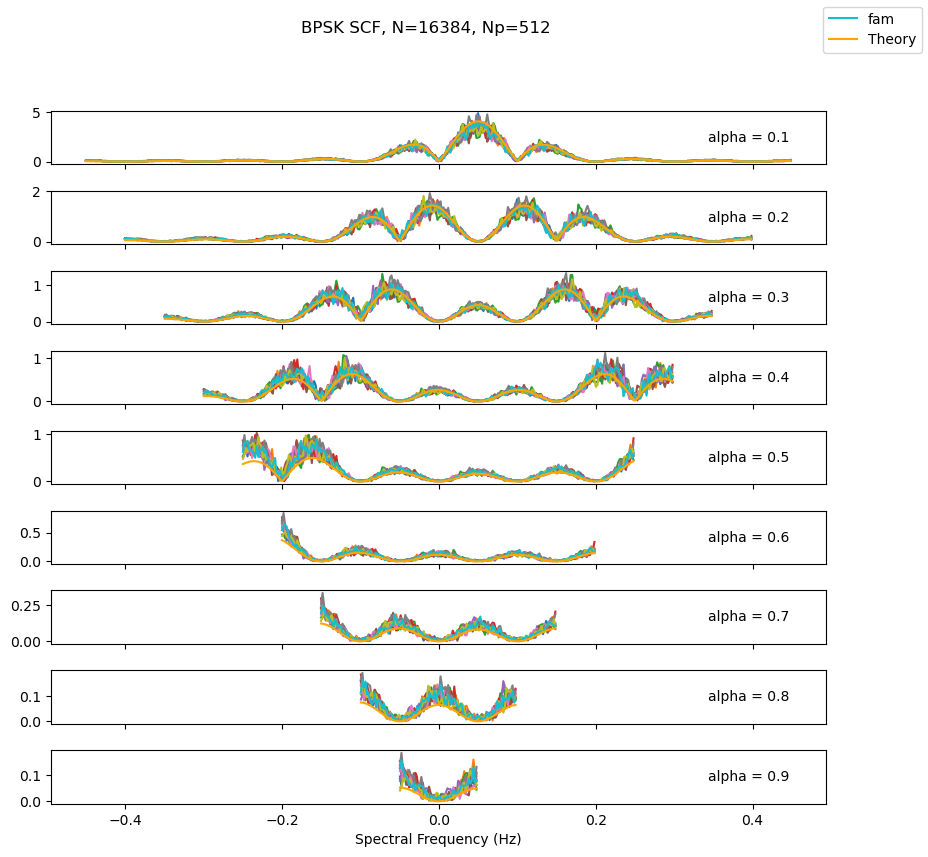

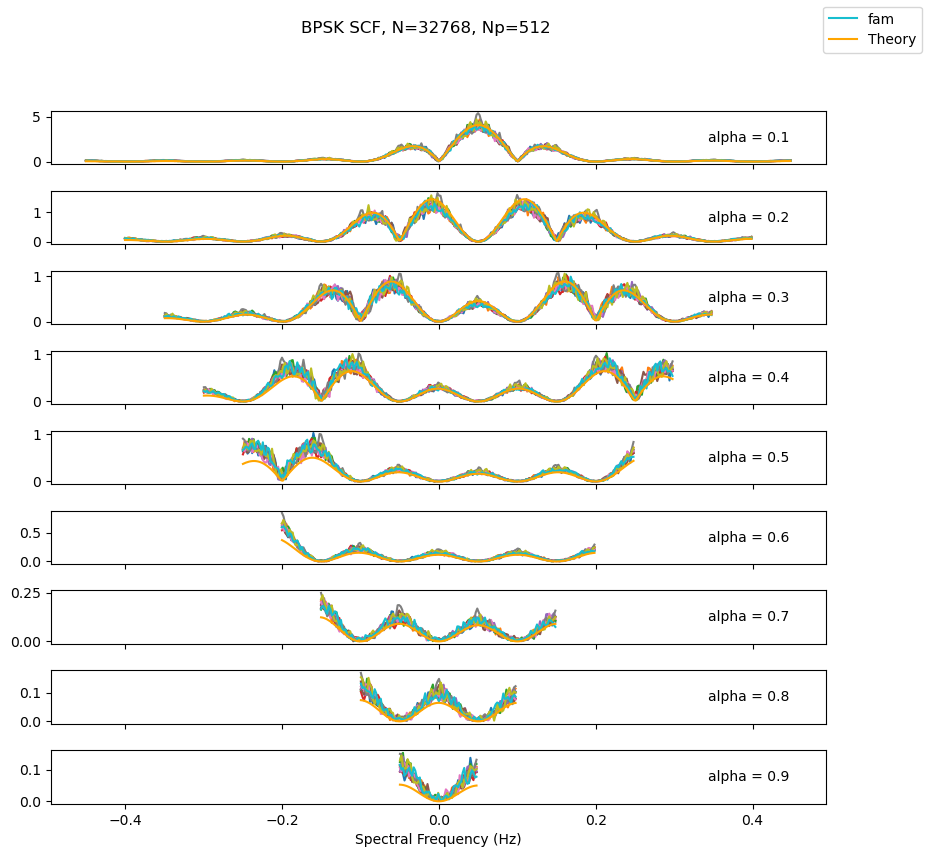

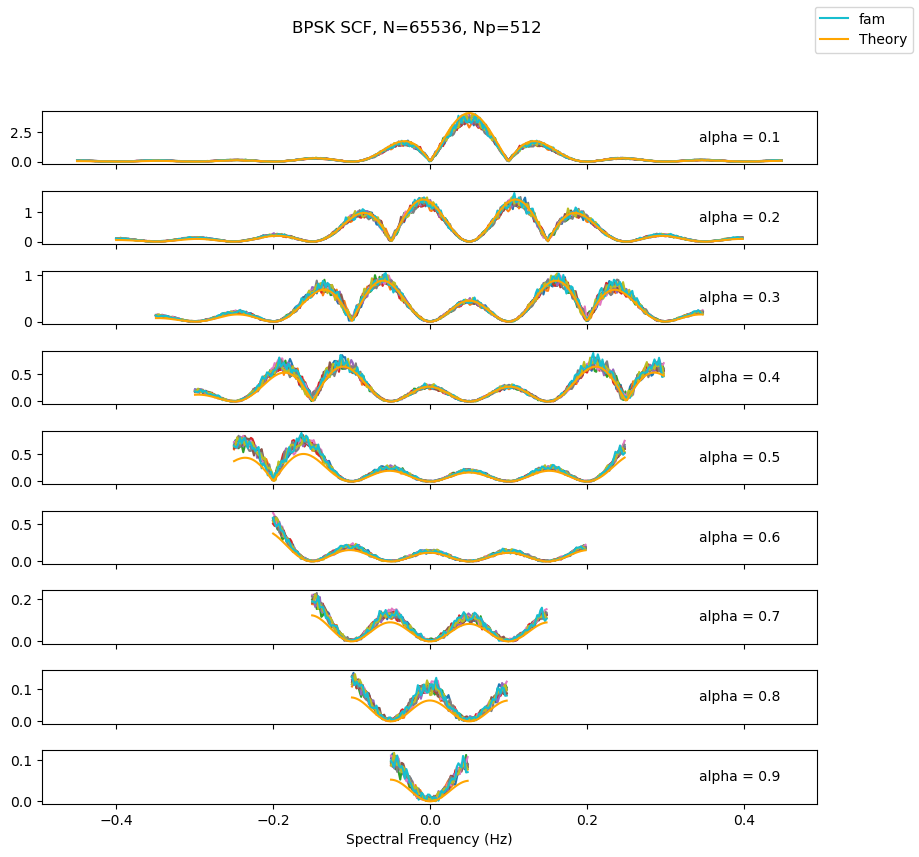

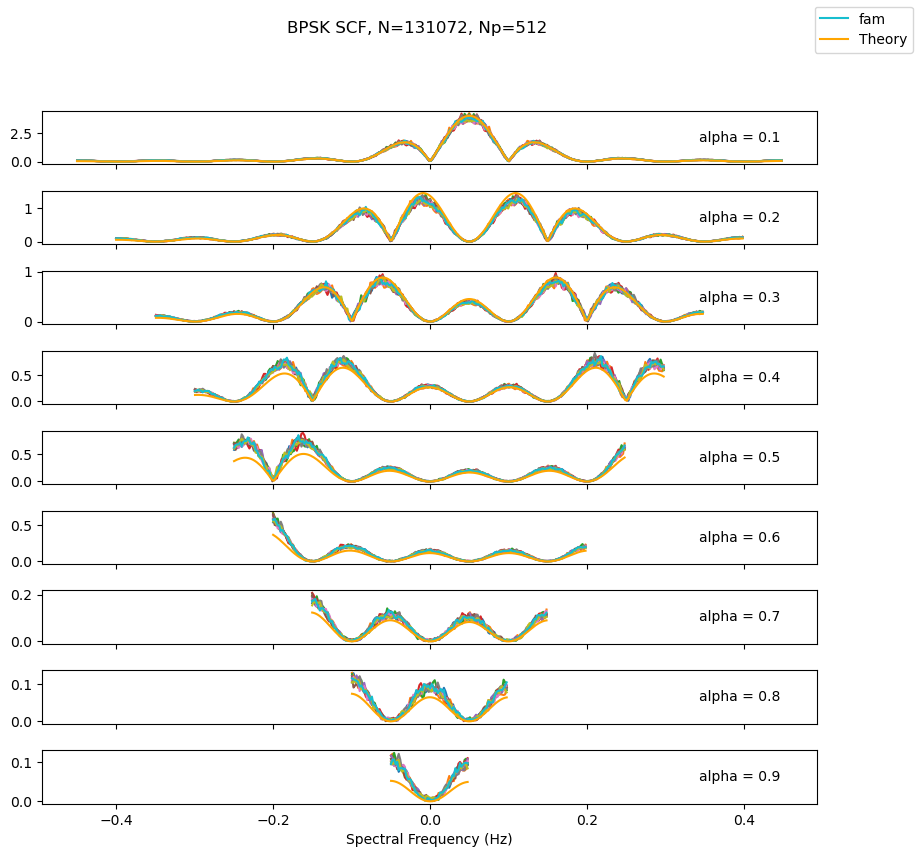

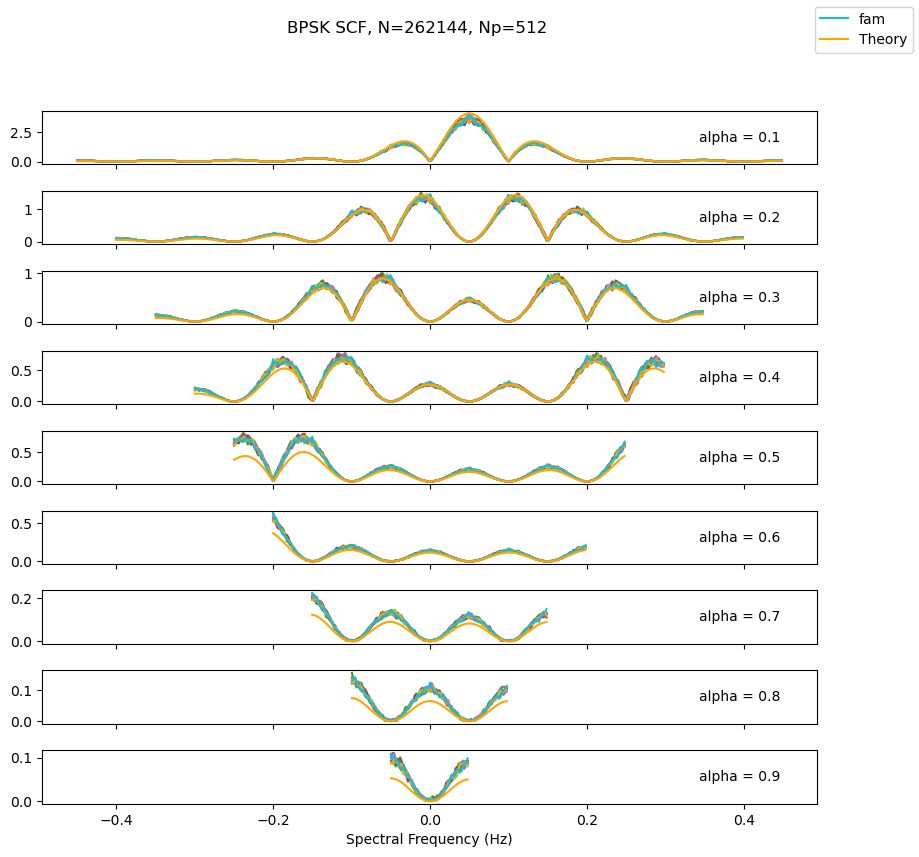

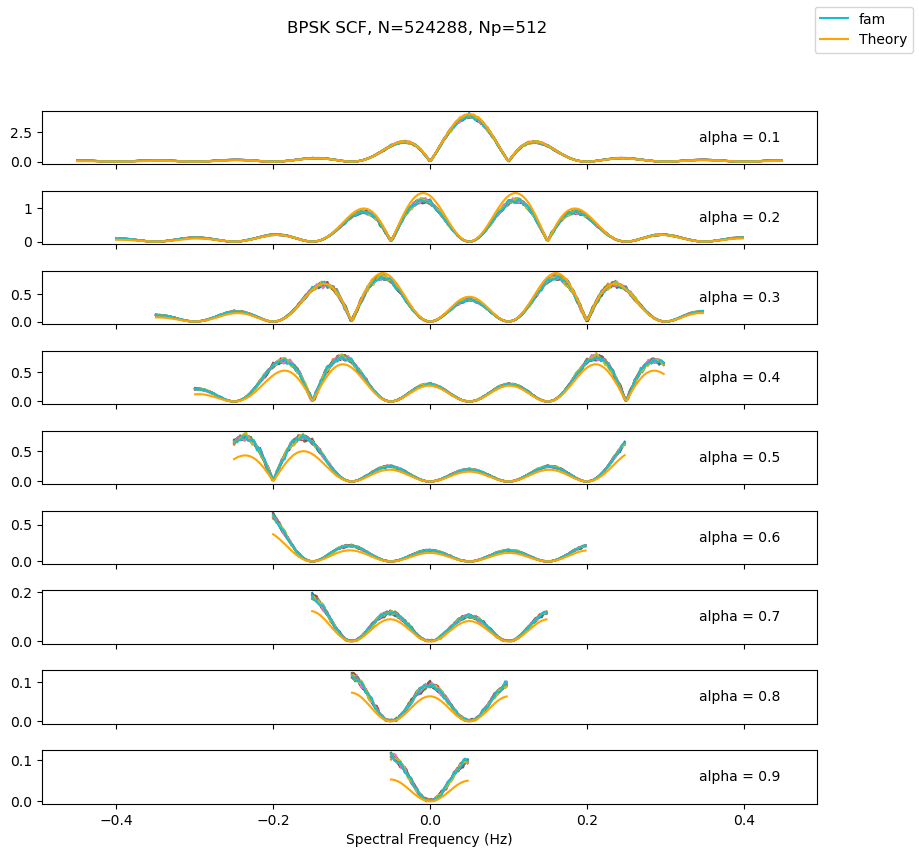

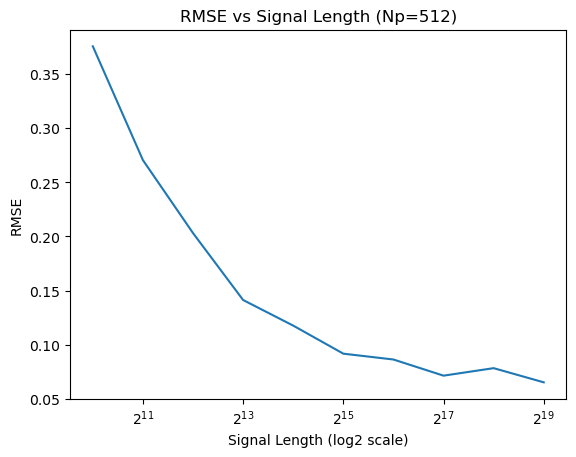

In [6]:
fam_rmse, no_of_points = test.validation_test(fam, name="fam", Np=512, snr=10, no_of_run=10, conjugate=False, save=True, fam=True)

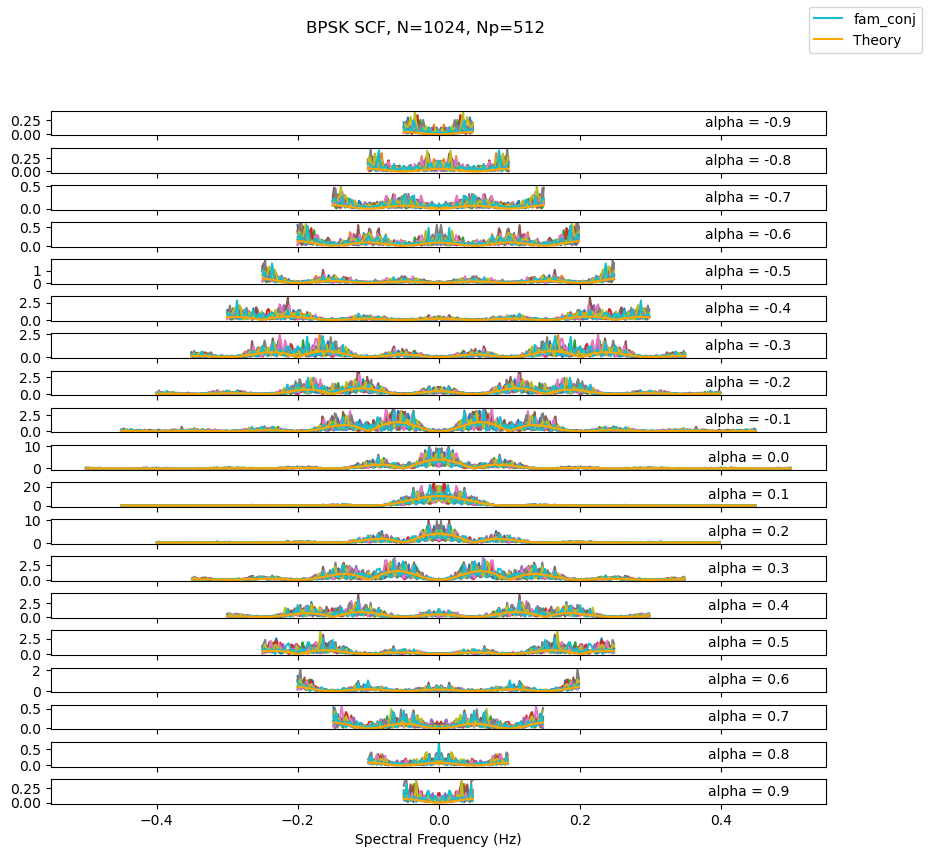

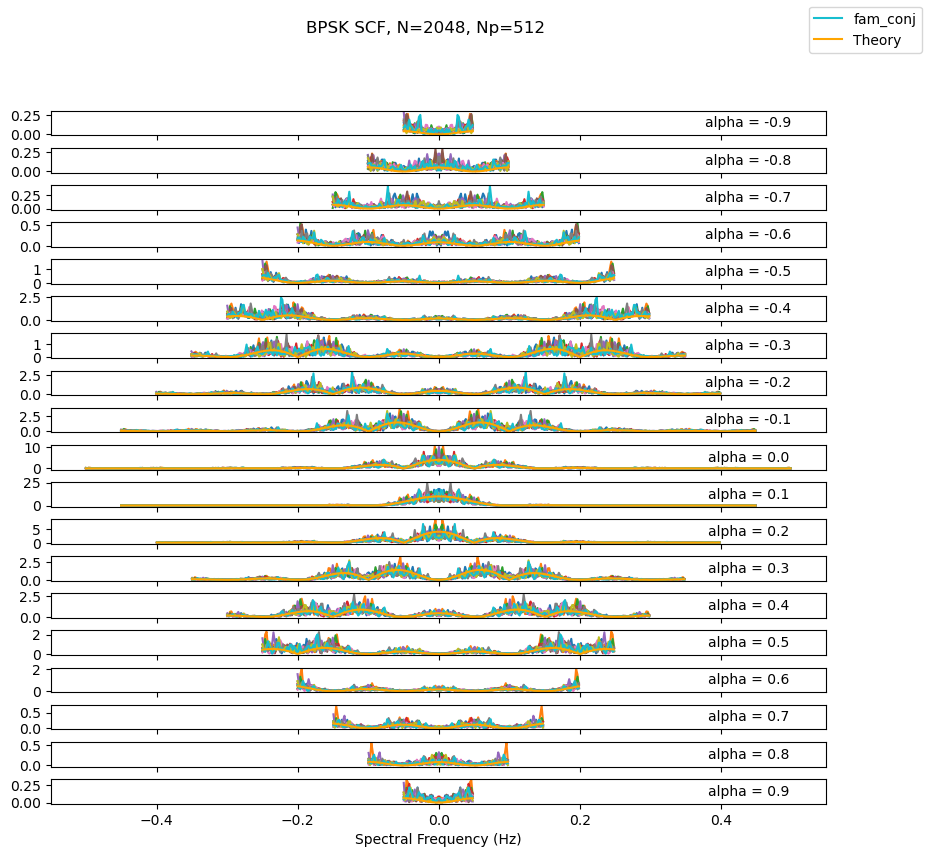

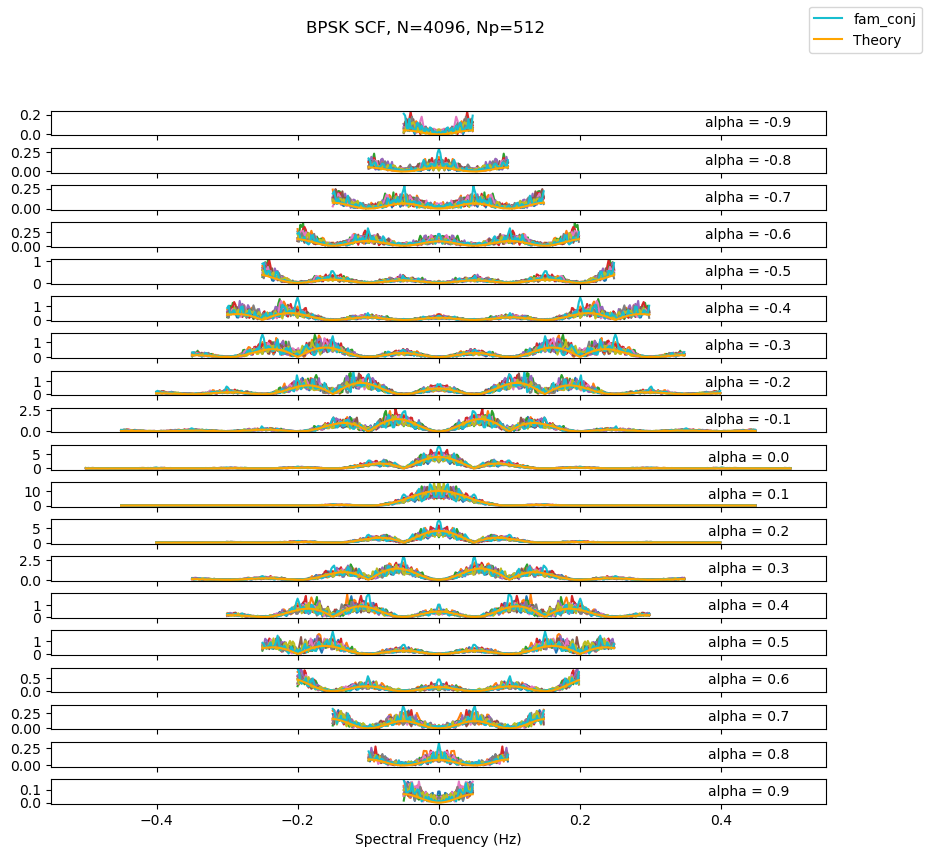

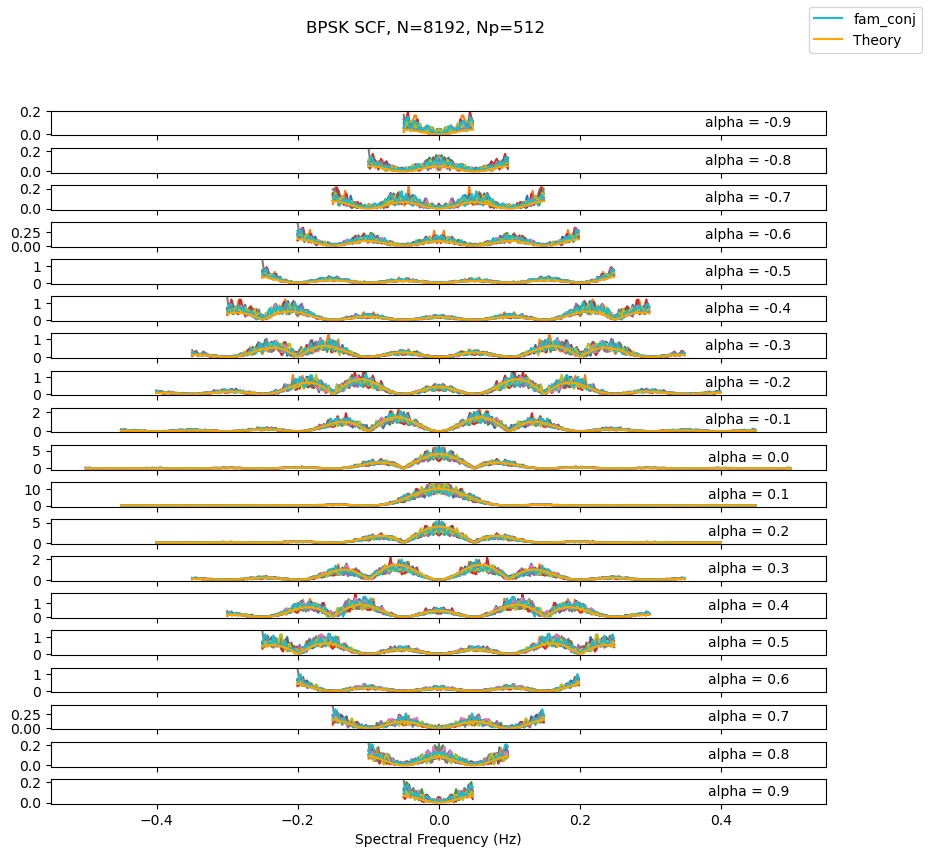

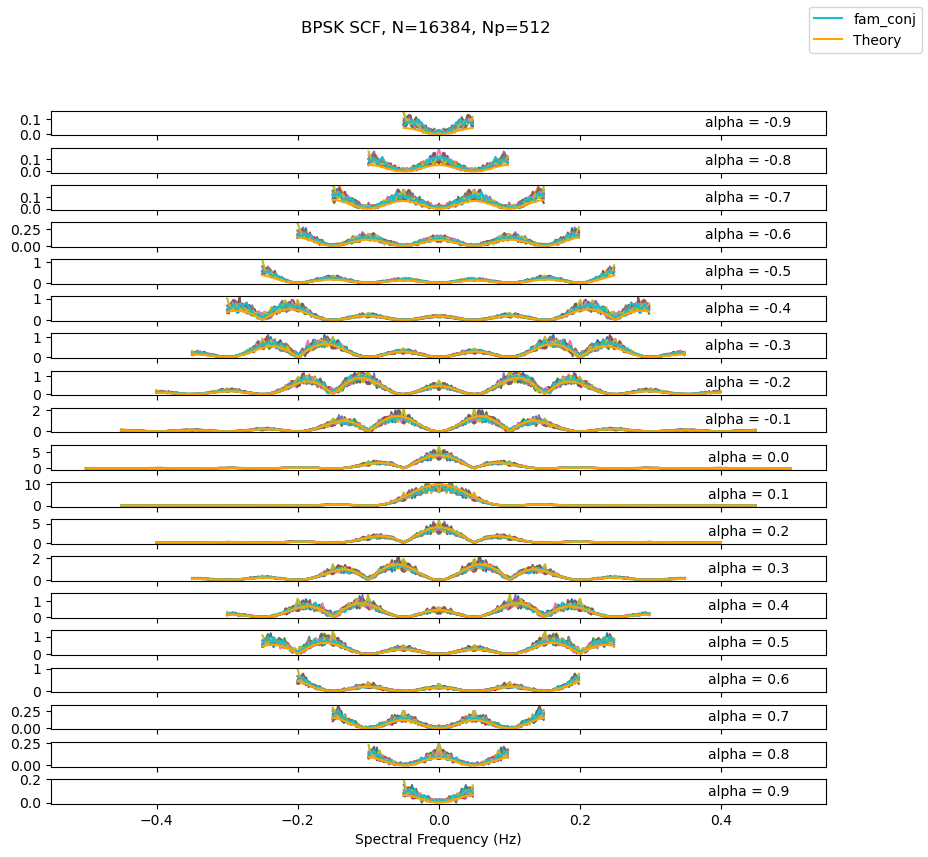

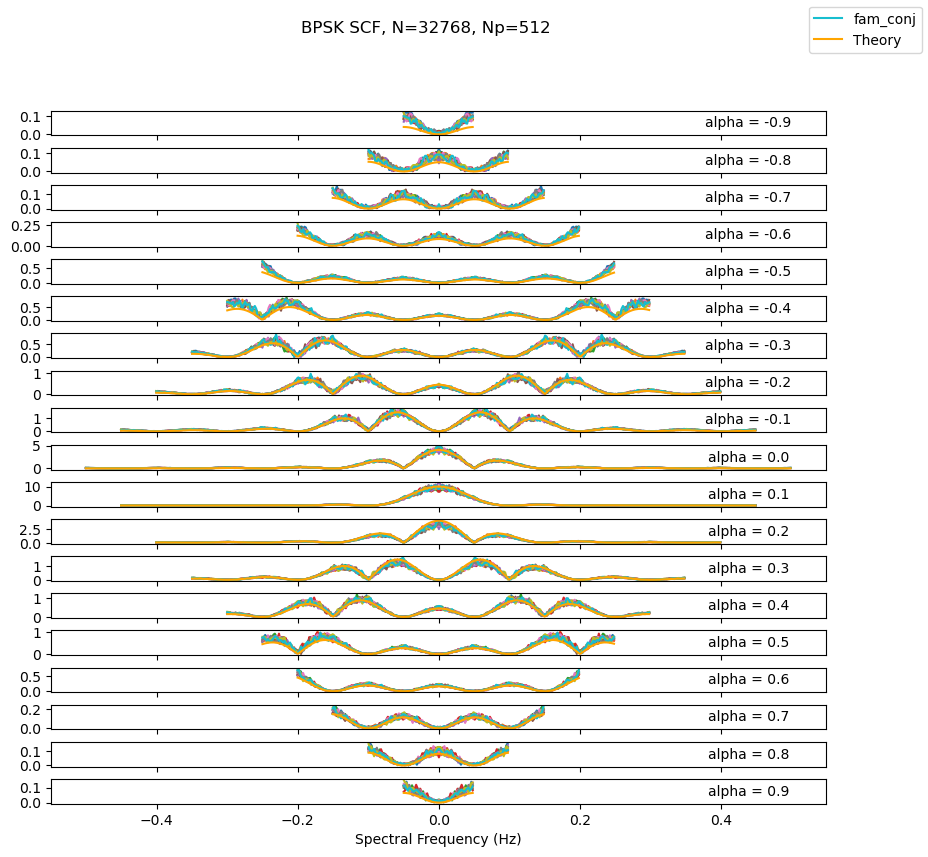

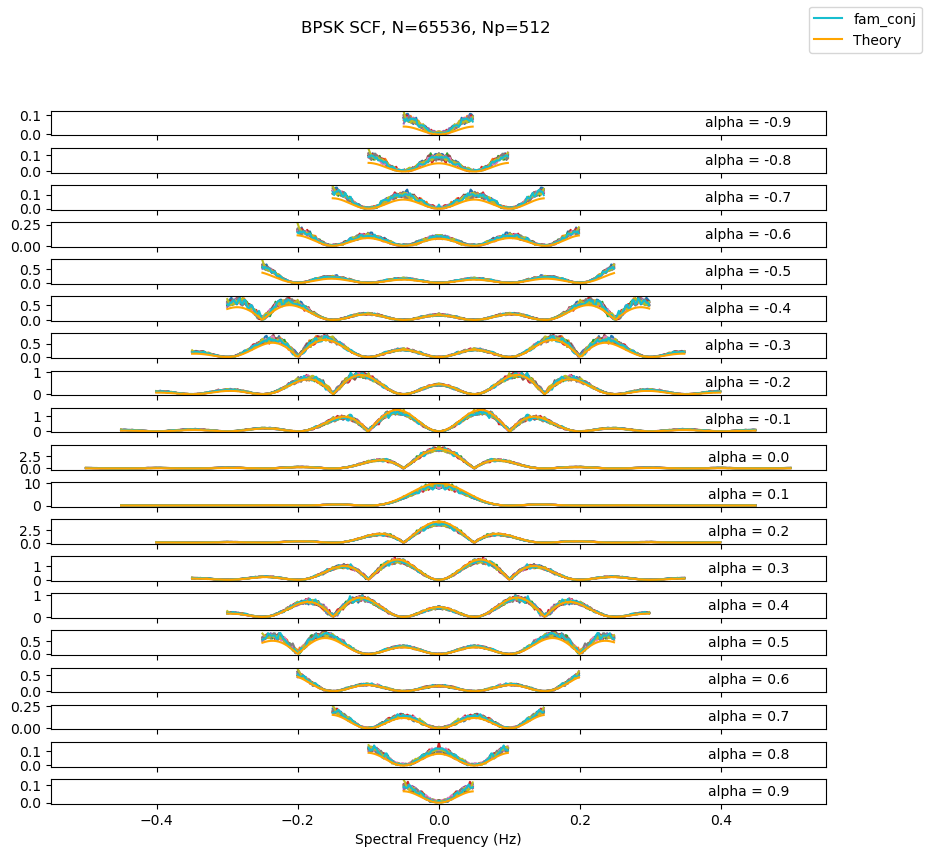

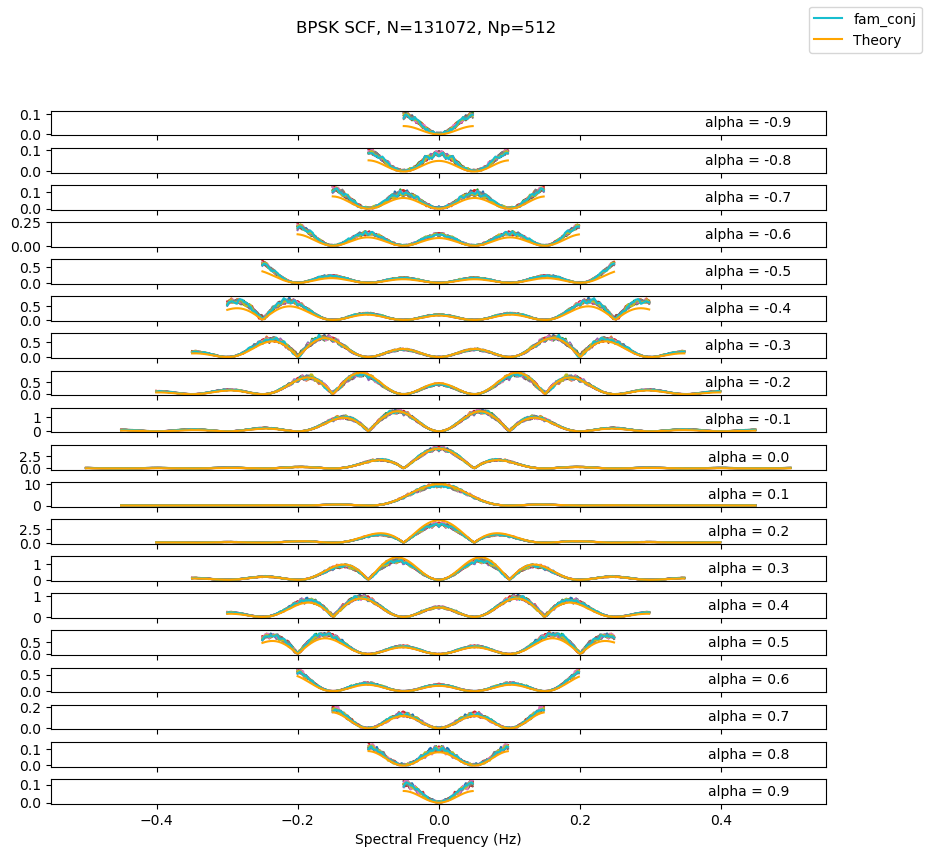

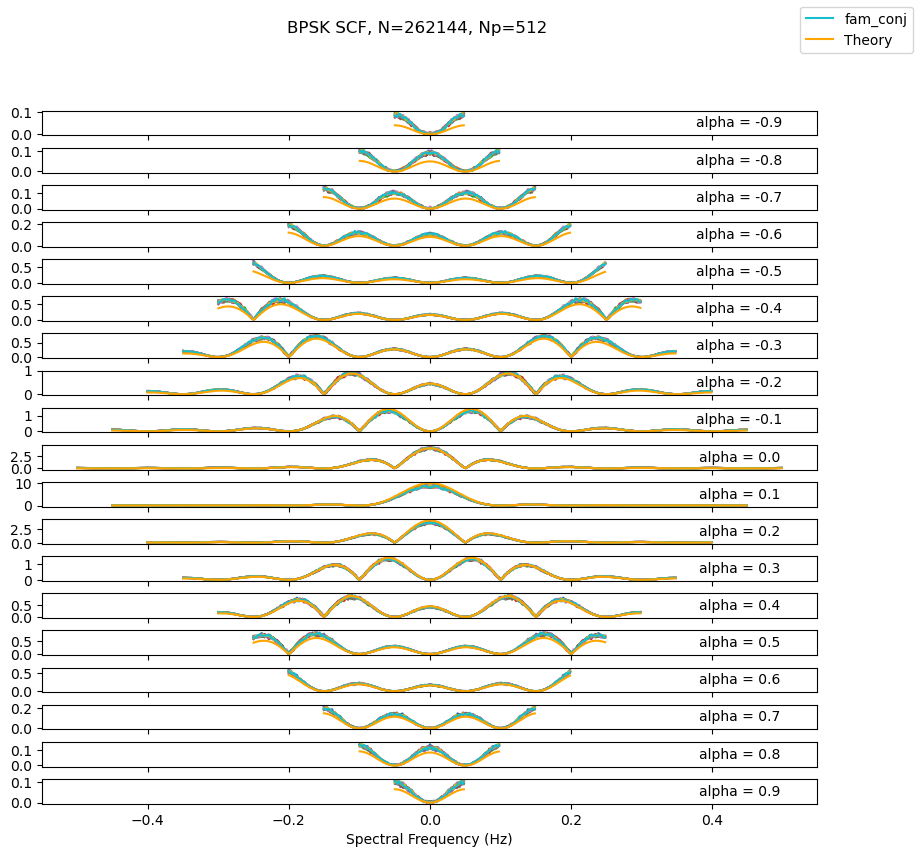

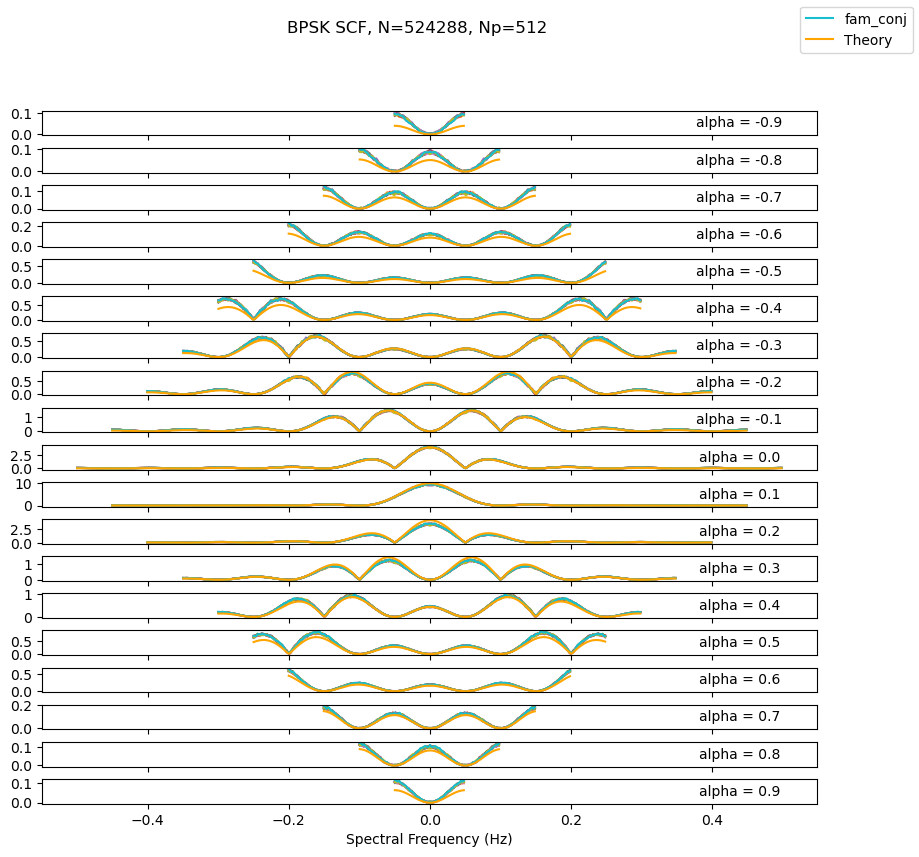

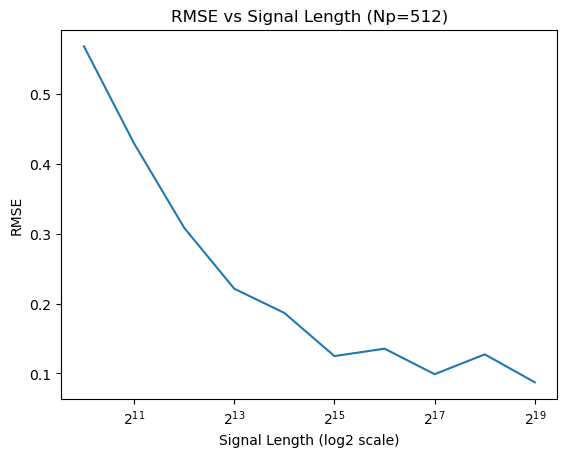

In [7]:
fam_conj_rmse, no_of_points = test.validation_test(fam, name="fam_conj", Np=512, snr=10, no_of_run=10, conjugate=True, save=True, fam=True)

In [3]:
test.window_test(ssca)

np.float64(0.14307217887804885)

In [4]:
test.window_test(fam)

np.float64(0.16355117479230508)

In [11]:
fam_peak_usage_8, fam_standard_deviation_8, length = test.memory_test(fam, name="FAM", plot=False)
fam_peak_usage_32, fam_standard_deviation_32, length = test.memory_test(fam, name="FAM", Np=32, plot=False)
fam_peak_usage_128, fam_standard_deviation_128, length = test.memory_test(fam, name="FAM", Np=128, plot=False)

ssca_peak_usage_8, ssca_standard_deviation_8, length = test.memory_test(ssca, name="SSCA", plot=False)
ssca_peak_usage_32, ssca_standard_deviation_32, length = test.memory_test(ssca, name="SSCA", Np=32, plot=False)
ssca_peak_usage_128, ssca_standard_deviation_128, length = test.memory_test(ssca, name="SSCA", Np=128, plot=False)

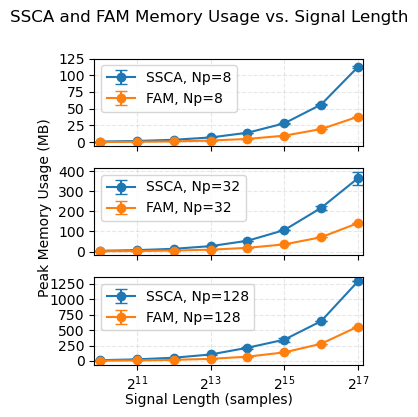

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(3.5, 4), sharex=True)
plt.suptitle('SSCA and FAM Memory Usage vs. Signal Length', y=0.995)
fig.text(0.5, 0.01, 'Signal Length (samples)', ha='center')
fig.text(0.01, 0.5, 'Peak Memory Usage (MB)', va='center', rotation='vertical')

axes[0].errorbar(length, ssca_peak_usage_8, yerr=ssca_standard_deviation_8, marker='o', capsize=4, label="SSCA, Np=8")
axes[0].errorbar(length, fam_peak_usage_8, yerr=fam_standard_deviation_8, marker='o', capsize=4, label="FAM, Np=8")
axes[0].set_xscale('log', base=2)
axes[0].legend()
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_yticks([0, 25, 50, 75, 100, 125])

axes[1].errorbar(length, ssca_peak_usage_32, yerr=ssca_standard_deviation_32, marker='o', capsize=4, label="SSCA, Np=32")
axes[1].errorbar(length, fam_peak_usage_32, yerr=fam_standard_deviation_32, marker='o', capsize=4, label="FAM, Np=32")
axes[1].set_xscale('log', base=2)
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_yticks([0, 100, 200, 300, 400])

axes[2].errorbar(length, ssca_peak_usage_128, yerr=ssca_standard_deviation_128, marker='o', capsize=4, label="SSCA, Np=128")
axes[2].errorbar(length, fam_peak_usage_128, yerr=fam_standard_deviation_128, marker='o', capsize=4, label="FAM, Np=128")
axes[2].set_xscale('log', base=2)
axes[2].set_xlim(length[0] * 0.9, length[-1] * 1.1)
axes[2].legend()
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].set_yticks([0, 250, 500, 750, 1000, 1250])

plt.tight_layout()
plt.show()

Loading data from: .benchmarks\Windows-CPython-3.13-64bit\0008_speed_test.json

Processed DataFrame:
  algorithm  np      mean    stddev
0      ssca   8  0.016017  0.001223
7       fam   8  0.023036  0.001656
1      ssca  16  0.030311  0.001038
8       fam  16  0.042457  0.006839
9       fam  32  0.083779  0.012763


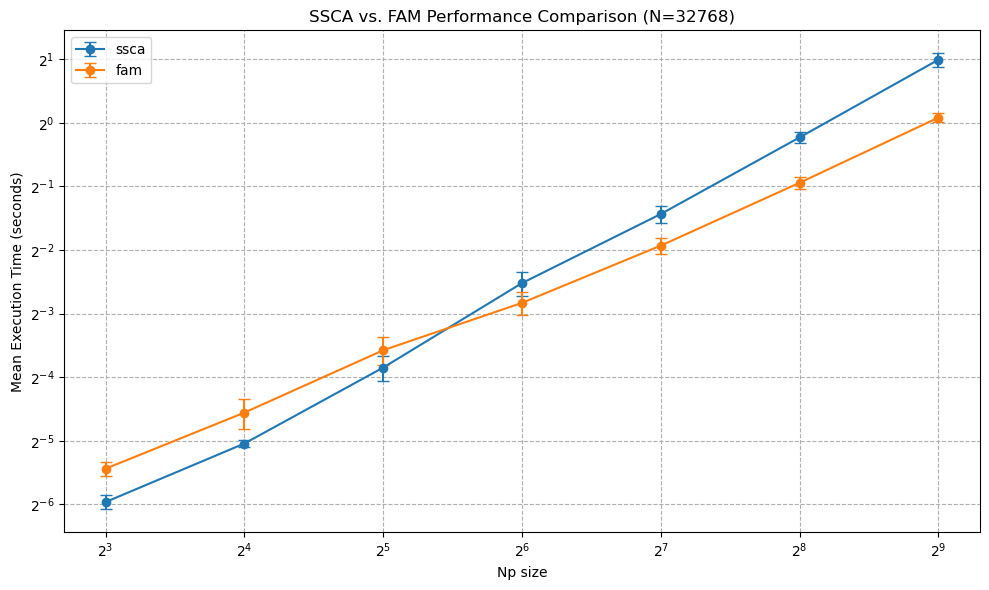

In [3]:
name = "ssca_vs_fam_np.py"

test.speed_test(name, algorithm_name=['ssca', 'fam'], plot=True)